In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pd.options.display.float_format = '{:20.2f}'.format   #make reading numbers easier
pd.set_option('display.max_column', 999)
plt.style.use('ggplot')

In [5]:
df= pd.read_csv('Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2021_20251031.csv', encoding="ISO-8859-1")

C:\Users\Kwame\AppData\Local\Temp\ipykernel_31940\1031095996.py:1: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2021_20251031.csv', encoding="ISO-8859-1")


In [6]:
df.shape

(2135260, 33)

In [7]:
df.head(20)

,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,Length of Stay,Type of Admission,Patient Disposition,Discharge Year,CCSR Diagnosis Code,CCSR Diagnosis Description,CCSR Procedure Code,CCSR Procedure Description,APR DRG Code,APR DRG Description,APR MDC Code,APR MDC Description,APR Severity of Illness Code,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,New York City,Bronx,7000006.00,1169.00,Montefiore Medical Center - Henry & Lucy Moses...,70 or Older,104,M,Other Race,Spanish/Hispanic,27,Emergency,Home w/ Home Health Services,2021,INF012,COVID-19,OTR004,ISOLATION PROCEDURES,137,MAJOR RESPIRATORY INFECTIONS AND INFLAMMATIONS,4,DISEASES AND DISORDERS OF THE RESPIRATORY SYSTEM,3,Major,Extreme,Medical,Medicare,Medicaid,NaN,NaN,Y,"$320,922.43","$60,241.34"
1,New York City,Bronx,7000006.00,1169.00,Montefiore Medical Center - Henry & Lucy Moses...,50 to 69,104,F,White,Not Span/Hispanic,4,Emergency,Home or Self Care,2021,NVS005,Multiple sclerosis,NaN,NaN,43,"MULTIPLE SCLEROSIS, OTHER DEMYELINATING DISEAS...",1,DISEASES AND DISORDERS OF THE NERVOUS SYSTEM,2,Moderate,Minor,Medical,Private Health Insurance,NaN,NaN,NaN,Y,"$61,665.22","$9,180.69"
2,New York City,Bronx,7000006.00,1168.00,Montefiore Medical Center-Wakefield Hospital,18 to 29,104,F,Other Race,Spanish/Hispanic,2,Emergency,Home or Self Care,2021,PRG016,Previous C-section,PGN003,CESAREAN SECTION,540,CESAREAN SECTION WITHOUT STERILIZATION,14,"PREGNANCY, CHILDBIRTH AND THE PUERPERIUM",1,Minor,Minor,Surgical,Medicaid,NaN,NaN,NaN,N,"$42,705.34","$11,366.5"
3,New York City,Bronx,7000006.00,3058.00,Montefiore Med Center - Jack D Weiler Hosp of ...,70 or Older,104,M,Other Race,Spanish/Hispanic,5,Emergency,Home or Self Care,2021,GEN004,Urinary tract infections,ADM017,ADMINISTRATION OF NUTRITIONAL AND ELECTROLYTIC...,463,KIDNEY AND URINARY TRACT INFECTIONS,11,DISEASES AND DISORDERS OF THE KIDNEY AND URINA...,3,Major,Major,Medical,Medicare,Medicaid,NaN,NaN,Y,"$72,700.17","$12,111.75"
4,New York City,Bronx,7000006.00,1169.00,Montefiore Medical Center - Henry & Lucy Moses...,50 to 69,104,F,Black/African American,Not Span/Hispanic,3,Emergency,Home or Self Care,2021,NVS008,Paralysis (other than cerebral palsy),CNS002,LUMBAR PUNCTURE,58,OTHER DISORDERS OF NERVOUS SYSTEM,1,DISEASES AND DISORDERS OF THE NERVOUS SYSTEM,2,Moderate,Minor,Medical,Medicare,Medicaid,NaN,NaN,Y,"$55,562.51","$8,339.72"
5,New York City,Bronx,7000006.00,3058.00,Montefiore Med Center - Jack D Weiler Hosp of ...,50 to 69,105,M,Other Race,Spanish/Hispanic,6,Emergency,Home or Self Care,2021,INJ037,Complication of other surgical or medical care...,IMG007,COMPUTERIZED TOMOGRAPHY (CT) WITHOUT CONTRAST,813,OTHER COMPLICATIONS OF TREATMENT,21,"INJURIES, POISONINGS AND TOXIC EFFECTS OF DRUGS",3,Major,Moderate,Medical,Private Health Insurance,NaN,NaN,NaN,Y,"$109,269.27","$18,443"
6,New York City,Bronx,7000006.00,1169.00,Montefiore Medical Center - Henry & Lucy Moses...,50 to 69,104,F,Black/African American,Not Span/Hispanic,1,Emergency,Home or Self Care,2021,INJ008,"Traumatic brain injury (TBI); concussion, init...",NaN,NaN,55,HEAD TRAUMA WITH COMA > 1 HOUR OR HEMORRHAGE,1,DISEASES AND DISORDERS OF THE NERVOUS SYSTEM,1,Minor,Minor,Medical,Medicare,Medicaid,NaN,NaN,Y,"$24,437.19","$3,060.38"
7,New York City,Bronx,7000006.00,3058.00,Montefiore Med Center - Jack D Weiler Hosp of ...,0 to 17,104,M,Other Race,Not Span/Hispanic,3,Newborn,Home or Self Care,2021,PNL001,Liveborn,ADM010,VACCINATIONS,640,"NEONATE BIRTH WEIGHT > 2499 GRAMS, NORMAL NEWB...",15,NEWBORNS AND OTHER NEONATES WITH CONDITIONS OR...,2,Moderate,Minor,Medical,Medicaid,NaN,NaN,3100.00,N,"$25,496.68","$3,544.65"
8,New York City,Bronx,7000006.00,1169.00,Montefiore Medical Center - Henry & Lucy Moses..

In [8]:
facility_map = df[['Permanent Facility Id', 'Facility Name']].drop_duplicates()
facility_map = dict(zip(facility_map['Permanent Facility Id'], facility_map['Facility Name']))

In [9]:
facility_map

{1169.0: 'Montefiore Medical Center - Henry & Lucy Moses Div',
 1168.0: 'Montefiore Medical Center-Wakefield Hospital',
 3058.0: 'Montefiore Med Center - Jack D Weiler Hosp of A Einstein College Div',
 1438.0: 'Bellevue Hospital Center',
 1294.0: 'Coney Island Hospital',
 1692.0: 'Woodhull Medical & Mental Health Center',
 1172.0: 'Lincoln Medical & Mental Health Center',
 1633.0: 'Queens Hospital Center',
 1186.0: 'North Central Bronx Hospital',
 1454.0: 'Metropolitan Hospital Center',
 1445.0: 'Harlem Hospital Center',
 1165.0: 'Jacobi Medical Center',
 1301.0: 'Kings County Hospital Center',
 nan: 'Redacted for Confidentiality',
 776.0: 'Montefiore Nyack',
 1456.0: 'Mount Sinai Hospital',
 1626.0: 'Elmhurst Hospital Center',
 1072.0: 'Montefiore New Rochelle Hospital',
 1061.0: 'Montefiore Mount Vernon Hospital',
 1466.0: 'Mount Sinai West',
 1486.0: 'Henry J. Carter Specialty Hospital',
 9059.0: 'Crouse Hospital - Commonwealth Division',
 1447.0: 'Hospital for Special Surgery',
 13

In [10]:
print(facility_map[1486.0])

Henry J. Carter Specialty Hospital


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2135260 entries, 0 to 2135259
Data columns (total 33 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   Hospital Service Area                object 
 1   Hospital County                      object 
 2   Operating Certificate Number         float64
 3   Permanent Facility Id                float64
 4   Facility Name                        object 
 5   Age Group                            object 
 6   Zip Code - 3 digits                  object 
 7   Gender                               object 
 8   Race                                 object 
 9   Ethnicity                            object 
 10  Length of Stay                       object 
 11  Type of Admission                    object 
 12  Patient Disposition                  object 
 13  Discharge Year                       int64  
 14  CCSR Diagnosis Code                  object 
 15  CCSR Diagnosis Description      

In [12]:
df.describe()

,Operating Certificate Number,Permanent Facility Id,Discharge Year,APR DRG Code,APR MDC Code,APR Severity of Illness Code
count,2128597.00,2130046.00,2135260.00,2135260.00,2135260.00,2135260.00
mean,4957985.46,1027.17,2021.00,414.05,10.31,2.14
std,2261388.30,715.22,0.00,244.07,5.97,0.98
min,101000.00,1.00,2021.00,1.00,0.00,0.00
25%,2951001.00,528.00,2021.00,194.00,5.00,1.00
50%,5902001.00,1045.00,2021.00,383.00,9.00,2.00
75%,7002020.00,1453.00,2021.00,640.00,15.00,3.00
max,7004010.00,10355.00,2021.00,956.00,25.00,4.00


In [13]:
df.describe(include='O')

,Hospital Service Area,Hospital County,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,Length of Stay,Type of Admission,Patient Disposition,CCSR Diagnosis Code,CCSR Diagnosis Description,CCSR Procedure Code,CCSR Procedure Description,APR DRG Description,APR MDC Description,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
count,2130046,2130046,2135260,2135260,2095014,2135260,2135260,2135260,2135260,2135260,2135260,2135260,2135260,1552073,1552073,2135260,2135260,2134671,2134671,2135260,2135260,1038259,332152,209927,2135260,2135260,2135260
unique,8,57,204,5,50,3,4,4,120,6,19,478,478,321,321,334,26,4,4,3,9,9,9,129,2,1846189,1568863
top,New York City,Manhattan,Mount Sinai Hospital,70 or Older,112,F,White,Not Span/Hispanic,2,Emergency,Home or Self Care,PNL001,Liveborn,PGN002,SPONTANEOUS VAGINAL DELIVERY,"NEONATE BIRTH WEIGHT > 2499 GRAMS, NORMAL NEWB...",DISEASES AND DISORDERS OF THE CIRCULATORY SYSTEM,Moderate,Minor,Medical,Medicare,Medicaid,Self-Pay,03200,Y,"$9,730",$548.32
freq,948517,366442,49972,630265,260307,1163725,1161894,1600636,471206,1405370,1397511,202001,202001,115171,115171,174868,263947,772195,1085541,1634307,841481,421231,204561,9568,1335897,520,526


In [14]:
df.isnull().sum()

Hospital Service Area                     5214
Hospital County                           5214
Operating Certificate Number              6663
Permanent Facility Id                     5214
Facility Name                                0
Age Group                                    0
Zip Code - 3 digits                      40246
Gender                                       0
Race                                         0
Ethnicity                                    0
Length of Stay                               0
Type of Admission                            0
Patient Disposition                          0
Discharge Year                               0
CCSR Diagnosis Code                          0
CCSR Diagnosis Description                   0
CCSR Procedure Code                     583187
CCSR Procedure Description              583187
APR DRG Code                                 0
APR DRG Description                          0
APR MDC Code                                 0
APR MDC Descr

In [15]:
df['Length of Stay'].unique()

array(['27', '4', '2', '5', '3', '6', '1', '21', '9', '14', '19', '24',
       '16', '7', '8', '11', '13', '10', '28', '120 +', '37', '22', '20',
       '33', '30', '15', '12', '46', '18', '29', '17', '43', '32', '25',
       '34', '53', '38', '23', '83', '103', '35', '36', '42', '44', '57',
       '45', '40', '84', '39', '31', '77', '71', '81', '54', '63', '41',
       '51', '58', '26', '99', '59', '97', '111', '49', '47', '56', '52',
       '80', '86', '74', '102', '48', '64', '68', '78', '55', '50', '72',
       '62', '70', '108', '66', '88', '61', '75', '73', '117', '67',
       '114', '116', '95', '113', '76', '60', '90', '115', '65', '118',
       '96', '69', '91', '93', '98', '94', '87', '106', '82', '85', '100',
       '119', '104', '92', '107', '79', '101', '89', '110', '109', '105',
       '112'], dtype=object)

In [16]:
cols= df[['Hospital Service Area', 'Hospital County',
       'Operating Certificate Number', 'Permanent Facility Id', 'Age Group', 'Zip Code - 3 digits', 'Gender', 'Race',
       'Ethnicity', 'Length of Stay', 'Type of Admission', 'Patient Disposition', 'Discharge Year', 'CCSR Diagnosis Code',
       'CCSR Procedure Code','APR DRG Code',
       'APR MDC Code', 'APR MDC Description', 'APR Severity of Illness Code',
       'APR Severity of Illness Description', 'APR Risk of Mortality',
       'APR Medical Surgical Description', 'Payment Typology 1',
       'Payment Typology 2', 'Payment Typology 3','Emergency Department Indicator']]

In [17]:
hospital_data = df[['Hospital Service Area', 'Hospital County',
                    'Permanent Facility Id', 'Age Group', 'Zip Code - 3 digits', 
                    'Gender', 'Race', 'Ethnicity', 'Length of Stay', 'Type of Admission',
                    'Patient Disposition', 'CCSR Diagnosis Code',
                    'CCSR Procedure Code','APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code',
                    'APR Risk of Mortality', 'APR Medical Surgical Description', 'Payment Typology 1']]

In [18]:
hospital_data[hospital_data['CCSR Procedure Code'].isna()]

,Hospital Service Area,Hospital County,Permanent Facility Id,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,Length of Stay,Type of Admission,Patient Disposition,CCSR Diagnosis Code,CCSR Procedure Code,APR DRG Code,APR MDC Code,APR Severity of Illness Code,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1
1,New York City,Bronx,1169.00,50 to 69,104,F,White,Not Span/Hispanic,4,Emergency,Home or Self Care,NVS005,NaN,43,1,2,Minor,Medical,Private Health Insurance
6,New York City,Bronx,1169.00,50 to 69,104,F,Black/African American,Not Span/Hispanic,1,Emergency,Home or Self Care,INJ008,NaN,55,1,1,Minor,Medical,Medicare
11,New York City,Bronx,1169.00,18 to 29,104,M,Black/African American,Not Span/Hispanic,3,Emergency,Home or Self Care,BLD005,NaN,662,16,3,Minor,Medical,Private Health Insurance
12,New York City,Bronx,1169.00,0 to 17,104,M,Other Race,Not Span/Hispanic,1,Emergency,Home or Self Care,CIR039,NaN,663,16,1,Minor,Medical,Medicaid
15,New York City,Bronx,1169.00,70 or Older,104,F,Black/African American,Not Span/Hispanic,1,Emergency,Home or Self Care,NEO073,NaN,58,1,2,Minor,Medical,Medicare
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2135251,Hudson Valley,Rockland,776.00,50 to 69,109,M,Multi-racial,Not Span/Hispanic,9,Emergency,Skilled Nursing Home,GEN004,NaN,463,11,3,Moderate,Medical,Medicare
2135252,Hudson Valley,Rockland,776.00,0 to 17,109,M,Black/African American,Not Span/Hispanic,2,Newborn,Home or Self Care,PNL001,NaN,640,15,1,Minor,Medical,Medicaid
2135253,Hudson Valley,Rockland,776.00,50 to 69,109,M,Multi-racial,Not Span/Hispanic,2,Emergency,Home or Self Care,INJ022,NaN,812,21,3,Moderate,Medical,Private Health Insurance
2135257,Long Island,Suffolk,913.00,70 or Older,117,F,White,Not Span/Hispanic,3,Emergency,Skilled Nursing Home,INJ034,NaN,466,11,3,Major,Medical,Medicare


In [19]:
hospital_data

,Hospital Service Area,Hospital County,Permanent Facility Id,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,Length of Stay,Type of Admission,Patient Disposition,CCSR Diagnosis Code,CCSR Procedure Code,APR DRG Code,APR MDC Code,APR Severity of Illness Code,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1
0,New York City,Bronx,1169.00,70 or Older,104,M,Other Race,Spanish/Hispanic,27,Emergency,Home w/ Home Health Services,INF012,OTR004,137,4,3,Extreme,Medical,Medicare
1,New York City,Bronx,1169.00,50 to 69,104,F,White,Not Span/Hispanic,4,Emergency,Home or Self Care,NVS005,NaN,43,1,2,Minor,Medical,Private Health Insurance
2,New York City,Bronx,1168.00,18 to 29,104,F,Other Race,Spanish/Hispanic,2,Emergency,Home or Self Care,PRG016,PGN003,540,14,1,Minor,Surgical,Medicaid
3,New York City,Bronx,3058.00,70 or Older,104,M,Other Race,Spanish/Hispanic,5,Emergency,Home or Self Care,GEN004,ADM017,463,11,3,Major,Medical,Medicare
4,New York City,Bronx,1169.00,50 to 69,104,F,Black/African American,Not Span/Hispanic,3,Emergency,Home or Self Care,NVS008,CNS002,58,1,2,Minor,Medical,Medicare
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2135255,Long Island,Suffolk,913.00,70 or Older,117,M,White,Not Span/Hispanic,7,Emergency,Skilled Nursing Home,GEN004,MST023,951,11,3,Major,Surgical,Medicare
2135256,Long Island,Suffolk,913.00,70 or Older,117,M,White,Not Span/Hispanic,3,Emergency,Skilled Nursing Home,INJ033,ESA001,206,5,3,Major,Medical,Medicare
2135257,Long Island,Suffolk,913.00,70 or Older,117,F,White,Not Span/Hispanic,3,Emergency,Skilled Nursing Home,INJ034,NaN,466,11,3,Major,Medical,Medicare
2135258,Long Island,Suffolk,913.00,70 or Older,117,F,White,Not Span/Hispanic,5,Emergency,Home w/ Home Health Services,RSP012,NaN,133,4,2,Moderate,Medical,"Managed Care, Unspecified"


In [20]:
hospital_data.isna().sum()

Hospital Service Area                 5214
Hospital County                       5214
Permanent Facility Id                 5214
Age Group                                0
Zip Code - 3 digits                  40246
Gender                                   0
Race                                     0
Ethnicity                                0
Length of Stay                           0
Type of Admission                        0
Patient Disposition                      0
CCSR Diagnosis Code                      0
CCSR Procedure Code                 583187
APR DRG Code                             0
APR MDC Code                             0
APR Severity of Illness Code             0
APR Risk of Mortality                  589
APR Medical Surgical Description         0
Payment Typology 1                       0
dtype: int64

In [21]:
missing_percent= (hospital_data.isna().sum() / len(hospital_data)) * 100
missing_percent

Hospital Service Area                              0.24
Hospital County                                    0.24
Permanent Facility Id                              0.24
Age Group                                          0.00
Zip Code - 3 digits                                1.88
Gender                                             0.00
Race                                               0.00
Ethnicity                                          0.00
Length of Stay                                     0.00
Type of Admission                                  0.00
Patient Disposition                                0.00
CCSR Diagnosis Code                                0.00
CCSR Procedure Code                               27.31
APR DRG Code                                       0.00
APR MDC Code                                       0.00
APR Severity of Illness Code                       0.00
APR Risk of Mortality                              0.03
APR Medical Surgical Description                

In [22]:
#dropping missing values would still leave us more than adequate values for analysis.

inpatient_df= hospital_data.dropna()
inpatient_df.shape

(1521588, 19)

In [23]:
#percentage of cleaned data

len(inpatient_df)/len(df)

0.7126008073958207

In [24]:
inpatient_df.head()

,Hospital Service Area,Hospital County,Permanent Facility Id,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,Length of Stay,Type of Admission,Patient Disposition,CCSR Diagnosis Code,CCSR Procedure Code,APR DRG Code,APR MDC Code,APR Severity of Illness Code,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1
0,New York City,Bronx,1169.00,70 or Older,104,M,Other Race,Spanish/Hispanic,27,Emergency,Home w/ Home Health Services,INF012,OTR004,137,4,3,Extreme,Medical,Medicare
2,New York City,Bronx,1168.00,18 to 29,104,F,Other Race,Spanish/Hispanic,2,Emergency,Home or Self Care,PRG016,PGN003,540,14,1,Minor,Surgical,Medicaid
3,New York City,Bronx,3058.00,70 or Older,104,M,Other Race,Spanish/Hispanic,5,Emergency,Home or Self Care,GEN004,ADM017,463,11,3,Major,Medical,Medicare
4,New York City,Bronx,1169.00,50 to 69,104,F,Black/African American,Not Span/Hispanic,3,Emergency,Home or Self Care,NVS008,CNS002,58,1,2,Minor,Medical,Medicare
5,New York City,Bronx,3058.00,50 to 69,105,M,Other Race,Spanish/Hispanic,6,Emergency,Home or Self Care,INJ037,IMG007,813,21,3,Moderate,Medical,Private Health Insurance


In [25]:
#rename columns to lowercases
inpatient_df.columns=inpatient_df.columns.str.lower()

#rename columns: replace spaces with '_'
inpatient_df.columns = [s.strip().replace(' ', '_') for s in inpatient_df.columns]

In [26]:
inpatient_df.head()

,hospital_service_area,hospital_county,permanent_facility_id,age_group,zip_code_-_3_digits,gender,race,ethnicity,length_of_stay,type_of_admission,patient_disposition,ccsr_diagnosis_code,ccsr_procedure_code,apr_drg_code,apr_mdc_code,apr_severity_of_illness_code,apr_risk_of_mortality,apr_medical_surgical_description,payment_typology_1
0,New York City,Bronx,1169.00,70 or Older,104,M,Other Race,Spanish/Hispanic,27,Emergency,Home w/ Home Health Services,INF012,OTR004,137,4,3,Extreme,Medical,Medicare
2,New York City,Bronx,1168.00,18 to 29,104,F,Other Race,Spanish/Hispanic,2,Emergency,Home or Self Care,PRG016,PGN003,540,14,1,Minor,Surgical,Medicaid
3,New York City,Bronx,3058.00,70 or Older,104,M,Other Race,Spanish/Hispanic,5,Emergency,Home or Self Care,GEN004,ADM017,463,11,3,Major,Medical,Medicare
4,New York City,Bronx,1169.00,50 to 69,104,F,Black/African American,Not Span/Hispanic,3,Emergency,Home or Self Care,NVS008,CNS002,58,1,2,Minor,Medical,Medicare
5,New York City,Bronx,3058.00,50 to 69,105,M,Other Race,Spanish/Hispanic,6,Emergency,Home or Self Care,INJ037,IMG007,813,21,3,Moderate,Medical,Private Health Insurance


In [27]:

#rename columns
inpatient_df=inpatient_df.rename(columns= {'hospital_service_area': 'service_area',
                                           'hospital_county': 'county',
                                           'permanent_facility_id': 'facility_id',
                                           'zip_code_-_3_digits': 'zip_code',
                                           'ccsr_diagnosis_code': 'diagnosis_code',
                                           'ccsr_procedure_code': 'procedure_code',
                                           'apr_drg_code': 'drug_code',
                                           'apr_mdc_code': 'mdc_code',
                                           'apr_severity_of_illness_code': 'severity_code',
                                           'apr_risk_of_mortality': 'mortality_risk',
                                           'apr_medical_surgical_description': 'surgical_description',
                                           'payment_typology_1': 'payment_typology'})


In [28]:
inpatient_df['age_group']= inpatient_df['age_group'].str.replace('_', '-')

In [29]:
inpatient_df['age_group']= inpatient_df['age_group'].str.replace(' or Older', '+')

In [30]:
inpatient_df['facility_id']= inpatient_df['facility_id'].astype(int)

In [31]:
inpatient_df

,service_area,county,facility_id,age_group,zip_code,gender,race,ethnicity,length_of_stay,type_of_admission,patient_disposition,diagnosis_code,procedure_code,drug_code,mdc_code,severity_code,mortality_risk,surgical_description,payment_typology
0,New York City,Bronx,1169,70+,104,M,Other Race,Spanish/Hispanic,27,Emergency,Home w/ Home Health Services,INF012,OTR004,137,4,3,Extreme,Medical,Medicare
2,New York City,Bronx,1168,18 to 29,104,F,Other Race,Spanish/Hispanic,2,Emergency,Home or Self Care,PRG016,PGN003,540,14,1,Minor,Surgical,Medicaid
3,New York City,Bronx,3058,70+,104,M,Other Race,Spanish/Hispanic,5,Emergency,Home or Self Care,GEN004,ADM017,463,11,3,Major,Medical,Medicare
4,New York City,Bronx,1169,50 to 69,104,F,Black/African American,Not Span/Hispanic,3,Emergency,Home or Self Care,NVS008,CNS002,58,1,2,Minor,Medical,Medicare
5,New York City,Bronx,3058,50 to 69,105,M,Other Race,Spanish/Hispanic,6,Emergency,Home or Self Care,INJ037,IMG007,813,21,3,Moderate,Medical,Private Health Insurance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2135250,Hudson Valley,Rockland,776,30 to 49,109,F,Multi-racial,Not Span/Hispanic,5,Emergency,Home or Self Care,NVS002,CNS002,50,1,2,Moderate,Medical,Medicare
2135254,Long Island,Suffolk,913,70+,117,F,White,Not Span/Hispanic,3,Emergency,Skilled Nursing Home,INJ006,MST010,308,8,2,Major,Surgical,Medicare
2135255,Long Island,Suffolk,913,70+,117,M,White,Not Span/Hispanic,7,Emergency,Skilled Nursing Home,GEN004,MST023,951,11,3,Major,Surgical,Medicare
2135256,Long Island,Suffolk,913,70+,117,M,White,Not Span/Hispanic,3,Emergency,Skilled Nursing Home,INJ033,ESA001,206,5,3,Major,Medical,Medicare


In [32]:
inpatient_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1521588 entries, 0 to 2135259
Data columns (total 19 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   service_area          1521588 non-null  object
 1   county                1521588 non-null  object
 2   facility_id           1521588 non-null  int64 
 3   age_group             1521588 non-null  object
 4   zip_code              1521588 non-null  object
 5   gender                1521588 non-null  object
 6   race                  1521588 non-null  object
 7   ethnicity             1521588 non-null  object
 8   length_of_stay        1521588 non-null  object
 9   type_of_admission     1521588 non-null  object
 10  patient_disposition   1521588 non-null  object
 11  diagnosis_code        1521588 non-null  object
 12  procedure_code        1521588 non-null  object
 13  drug_code             1521588 non-null  int64 
 14  mdc_code              1521588 non-null  int64 
 15  sev

In [33]:
inpatient_df.to_csv("hospital_inpatient_cleaned_data.csv", index=False)

In [34]:
# Create a dictionary to map the string values to numerical categories
mortality_risk_mapping = {
    'Minor': 1,
    'Moderate': 2,
    'Major': 3,
    'Extreme': 4
}

In [35]:
# Use the .replace() method to apply the mapping to the 'mortality_risk' column
inpatient_df['mortality_risk'] = inpatient_df['mortality_risk'].replace(mortality_risk_mapping)

C:\Users\Kwame\AppData\Local\Temp\ipykernel_31940\429969006.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inpatient_df['mortality_risk'] = inpatient_df['mortality_risk'].replace(mortality_risk_mapping)


In [36]:
inpatient_df

,service_area,county,facility_id,age_group,zip_code,gender,race,ethnicity,length_of_stay,type_of_admission,patient_disposition,diagnosis_code,procedure_code,drug_code,mdc_code,severity_code,mortality_risk,surgical_description,payment_typology
0,New York City,Bronx,1169,70+,104,M,Other Race,Spanish/Hispanic,27,Emergency,Home w/ Home Health Services,INF012,OTR004,137,4,3,4,Medical,Medicare
2,New York City,Bronx,1168,18 to 29,104,F,Other Race,Spanish/Hispanic,2,Emergency,Home or Self Care,PRG016,PGN003,540,14,1,1,Surgical,Medicaid
3,New York City,Bronx,3058,70+,104,M,Other Race,Spanish/Hispanic,5,Emergency,Home or Self Care,GEN004,ADM017,463,11,3,3,Medical,Medicare
4,New York City,Bronx,1169,50 to 69,104,F,Black/African American,Not Span/Hispanic,3,Emergency,Home or Self Care,NVS008,CNS002,58,1,2,1,Medical,Medicare
5,New York City,Bronx,3058,50 to 69,105,M,Other Race,Spanish/Hispanic,6,Emergency,Home or Self Care,INJ037,IMG007,813,21,3,2,Medical,Private Health Insurance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2135250,Hudson Valley,Rockland,776,30 to 49,109,F,Multi-racial,Not Span/Hispanic,5,Emergency,Home or Self Care,NVS002,CNS002,50,1,2,2,Medical,Medicare
2135254,Long Island,Suffolk,913,70+,117,F,White,Not Span/Hispanic,3,Emergency,Skilled Nursing Home,INJ006,MST010,308,8,2,3,Surgical,Medicare
2135255,Long Island,Suffolk,913,70+,117,M,White,Not Span/Hispanic,7,Emergency,Skilled Nursing Home,GEN004,MST023,951,11,3,3,Surgical,Medicare
2135256,Long Island,Suffolk,913,70+,117,M,White,Not Span/Hispanic,3,Emergency,Skilled Nursing Home,INJ033,ESA001,206,5,3,3,Medical,Medicare


In [37]:
inpatient_df['length_of_stay']= inpatient_df['length_of_stay'].str.replace('120 +', '120')

In [38]:
inpatient_df['length_of_stay']= inpatient_df['length_of_stay'].astype(int)

In [39]:
inpatient_df.describe()

,facility_id,length_of_stay,drug_code,mdc_code,severity_code,mortality_risk
count,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00
mean,1073.56,6.23,412.44,10.29,2.20,1.92
std,720.04,9.09,238.81,5.76,1.01,1.10
min,1.00,1.00,1.00,1.00,1.00,1.00
25%,541.00,2.00,194.00,5.00,1.00,1.00
50%,1165.00,3.00,384.00,9.00,2.00,1.00
75%,1456.00,7.00,640.00,15.00,3.00,3.00
max,10355.00,120.00,952.00,25.00,4.00,4.00


In [40]:
# --- freq
group_cols = ['facility_id','diagnosis_code']
freq = inpatient_df.groupby(group_cols).size().reset_index(name='count_fd')
inpatient_df = inpatient_df.merge(freq, on=group_cols, how='left')
inpatient_df['freq_percentile'] = inpatient_df['count_fd'].rank(method='max', pct=True)


inpatient_df['severity_high']  = (inpatient_df['severity_code'] >= 3).astype(int)
inpatient_df['mortality_high'] = (inpatient_df['mortality_risk'] >= 3).astype(int)
inpatient_df['length_of_stay_high'] = (inpatient_df['length_of_stay'] >= 7).astype(int)
inpatient_df['clinical_score'] = inpatient_df[['severity_high','mortality_high','length_of_stay_high']].sum(axis=1)
inpatient_df['clinical_score_scaled'] = inpatient_df['clinical_score'] / 3.0

# --- combine
w_freq, w_clin = 0.4, 0.6
inpatient_df['combined_score'] = w_freq * inpatient_df['freq_percentile'] + w_clin * inpatient_df['clinical_score_scaled']

# --- threshold -> label
threshold = 0.5
inpatient_df['readmitted'] = (inpatient_df['combined_score'] >= threshold).astype(int)


In [41]:
inpatient_df

,service_area,county,facility_id,age_group,zip_code,gender,race,ethnicity,length_of_stay,type_of_admission,patient_disposition,diagnosis_code,procedure_code,drug_code,mdc_code,severity_code,mortality_risk,surgical_description,payment_typology,count_fd,freq_percentile,severity_high,mortality_high,length_of_stay_high,clinical_score,clinical_score_scaled,combined_score,readmitted
0,New York City,Bronx,1169,70+,104,M,Other Race,Spanish/Hispanic,27,Emergency,Home w/ Home Health Services,INF012,OTR004,137,4,3,4,Medical,Medicare,1224,0.87,1,1,1,3,1.00,0.95,1
1,New York City,Bronx,1168,18 to 29,104,F,Other Race,Spanish/Hispanic,2,Emergency,Home or Self Care,PRG016,PGN003,540,14,1,1,Surgical,Medicaid,68,0.25,0,0,0,0,0.00,0.10,0
2,New York City,Bronx,3058,70+,104,M,Other Race,Spanish/Hispanic,5,Emergency,Home or Self Care,GEN004,ADM017,463,11,3,3,Medical,Medicare,253,0.54,1,1,0,2,0.67,0.61,1
3,New York City,Bronx,1169,50 to 69,104,F,Black/African American,Not Span/Hispanic,3,Emergency,Home or Self Care,NVS008,CNS002,58,1,2,1,Medical,Medicare,14,0.07,0,0,0,0,0.00,0.03,0
4,New York City,Bronx,3058,50 to 69,105,M,Other Race,Spanish/Hispanic,6,Emergency,Home or Self Care,INJ037,IMG007,813,21,3,2,Medical,Private Health Insurance,262,0.55,1,0,0,1,0.33,0.42,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521583,Hudson Valley,Rockland,776,30 to 49,109,F,Multi-racial,Not Span/Hispanic,5,Emergency,Home or Self Care,NVS002,CNS002,50,1,2,2,Medical,Medicare,2,0.01,0,0,0,0,0.00,0.00,0
1521584,Long Island,Suffolk,913,70+,117,F,White,Not Span/Hispanic,3,Emergency,Skilled Nursing Home,INJ006,MST010,308,8,2,3,Surgical,Medicare,246,0.53,0,1,0,1,0.33,0.41,0
1521585,Long Island,Suffolk,913,70+,117,M,White,Not Span/Hispanic,7,Emergency,Skilled Nursing Home,GEN004,MST023,951,11,3,3,Surgical,Medicare,129,0.38,1,1,1,3,1.00,0.75,1
1521586,Long Island,Suffolk,913,70+,117,M,White,Not Span/Hispanic,3,Emergency,Skilled Nursing Home,INJ033,ESA001,206,5,3,3,Medical,Medicare,77,0.28,1,1,0,2,0.67,0.51,1


In [42]:
inpatient_df.columns

Index(['service_area', 'county', 'facility_id', 'age_group', 'zip_code',
       'gender', 'race', 'ethnicity', 'length_of_stay', 'type_of_admission',
       'patient_disposition', 'diagnosis_code', 'procedure_code', 'drug_code',
       'mdc_code', 'severity_code', 'mortality_risk', 'surgical_description',
       'payment_typology', 'count_fd', 'freq_percentile', 'severity_high',
       'mortality_high', 'length_of_stay_high', 'clinical_score',
       'clinical_score_scaled', 'combined_score', 'readmitted'],
      dtype='object')

In [43]:
inpatient_cleaned= inpatient_df[['service_area', 'county', 'facility_id', 'age_group', 'zip_code',
       'gender', 'race', 'ethnicity', 'length_of_stay', 'type_of_admission',
       'patient_disposition', 'diagnosis_code', 'procedure_code', 'drug_code',
       'mdc_code', 'severity_code', 'mortality_risk', 'surgical_description',
       'payment_typology', 'readmitted']]

In [44]:
inpatient_cleaned.to_csv("inpatient_cleaned.csv", index=False)

**Data Exploration**

In [45]:
inpatient_df['readmitted'].value_counts()

readmitted
0    1063785
1     457803
Name: count, dtype: int64

In [46]:
pp= inpatient_df['readmitted'].value_counts(normalize=True) * 100
pp

readmitted
0                  69.91
1                  30.09
Name: proportion, dtype: float64

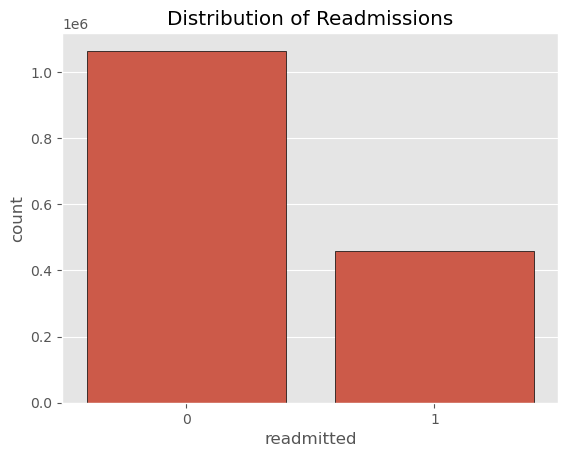

In [47]:
sns.countplot(x='readmitted', data=inpatient_df, edgecolor= 'black')
plt.title('Distribution of Readmissions')
plt.show()

In [48]:
readmission_rate = (inpatient_df['readmitted'] ==1) / (len(inpatient_df)) * 100

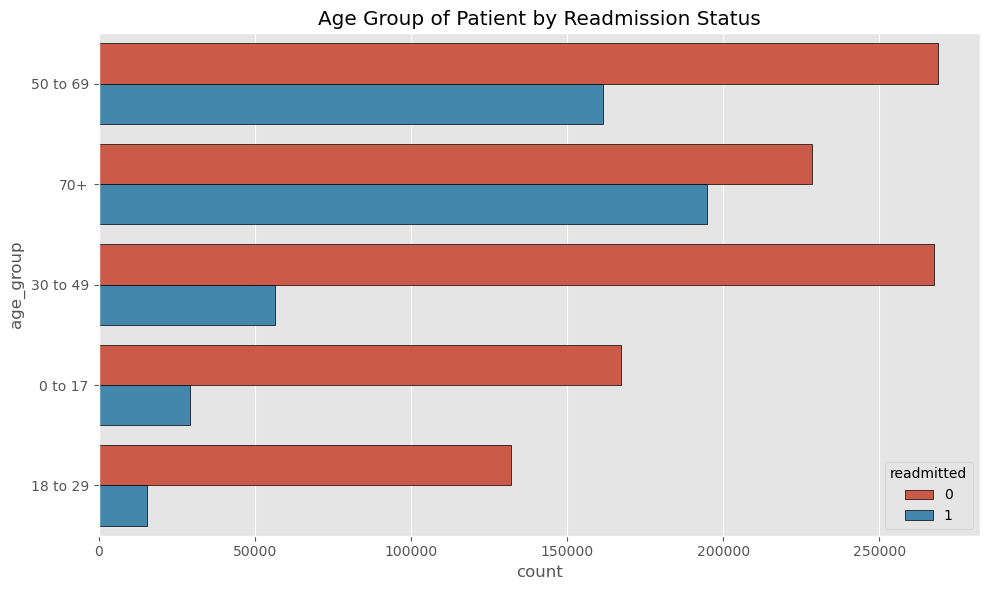

In [49]:
fig = plt.figure(figsize=(10,6))

order = inpatient_df['age_group'].value_counts().index

ax=sns.countplot(y= inpatient_df['age_group'], hue= inpatient_df['readmitted'], order=order, edgecolor='black')
ax.set_title('Age Group of Patient by Readmission Status')

plt.tight_layout()
plt.show()

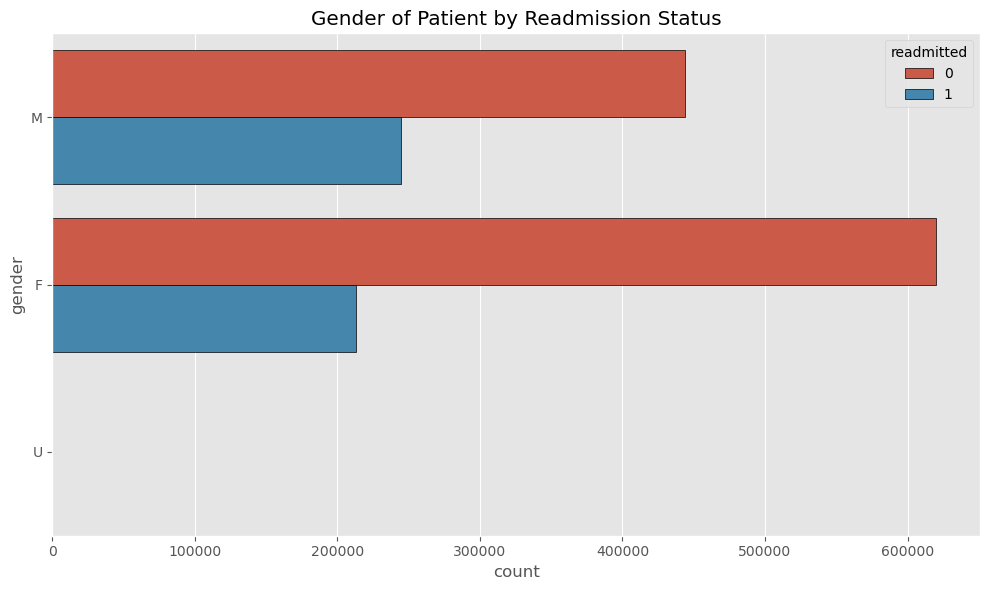

In [50]:
fig = plt.figure(figsize=(10,6))
ax=sns.countplot(y= inpatient_df['gender'], hue= inpatient_df['readmitted'], edgecolor='black')
ax.set_title('Gender of Patient by Readmission Status')

plt.tight_layout()
plt.show()

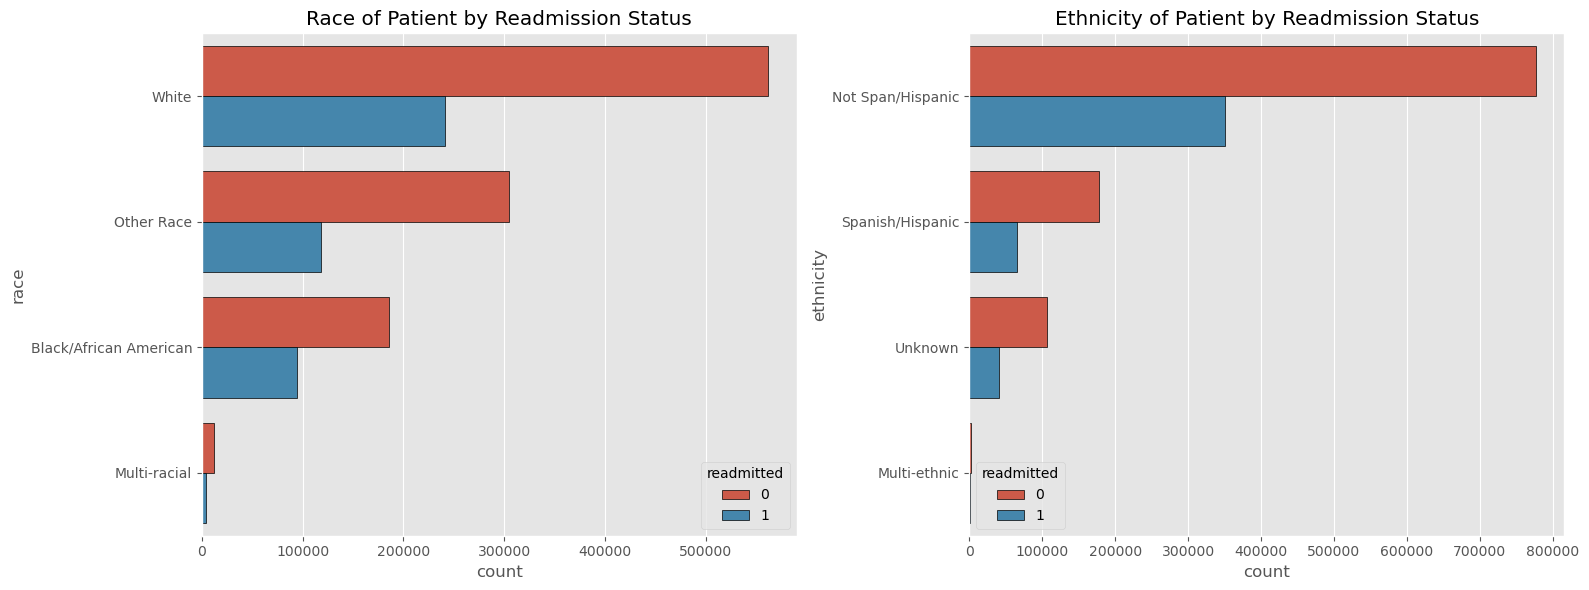

In [51]:
fig = plt.figure(figsize=(16,6))

order = inpatient_df['race'].value_counts().index
order2 = inpatient_df['ethnicity'].value_counts().index

plt.subplot(1,2,1)
ax=sns.countplot(y= inpatient_df['race'], hue= inpatient_df['readmitted'], order=order, edgecolor='black')
ax.set_title('Race of Patient by Readmission Status')

plt.subplot(1,2,2)
ax=sns.countplot(y= inpatient_df['ethnicity'], hue= inpatient_df['readmitted'], order=order2, edgecolor='black')
ax.set_title('Ethnicity of Patient by Readmission Status')


plt.tight_layout()
plt.show()

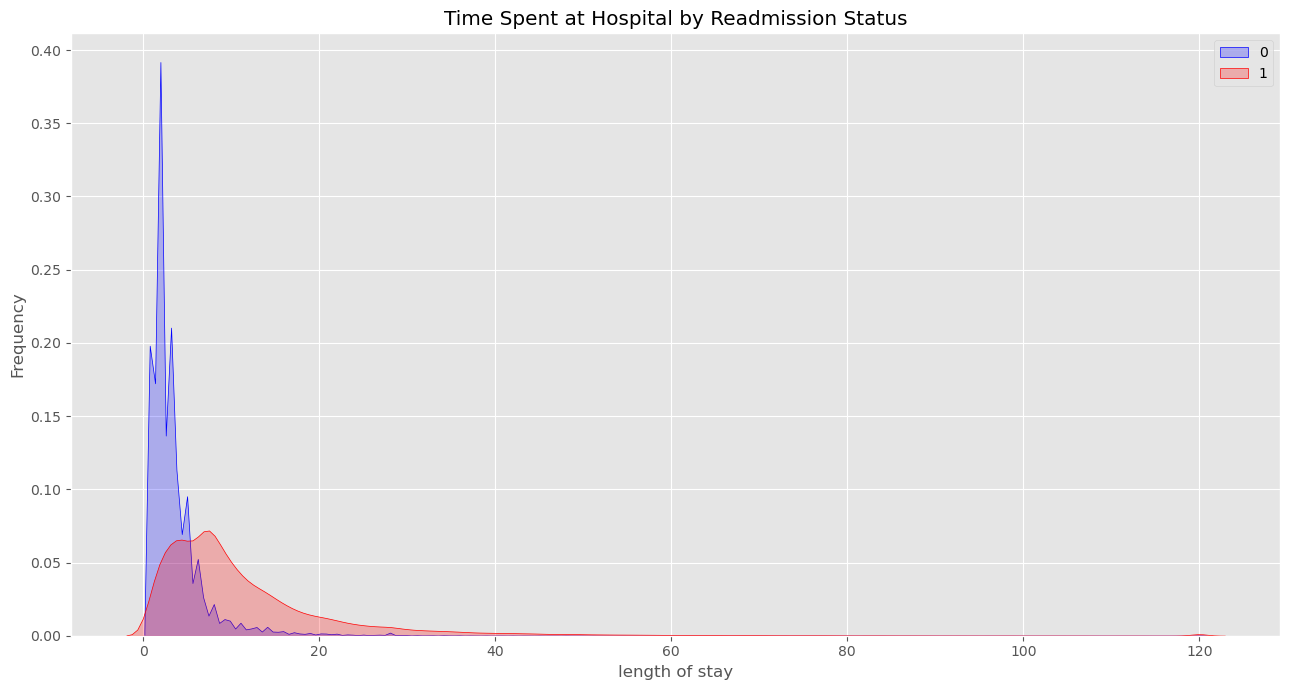

In [52]:
fig = plt.figure(figsize=(13,7),)

ax=sns.kdeplot(inpatient_df.loc[(inpatient_df['readmitted'] == 0),'length_of_stay'] , color='b',fill=True,label='Not Readmitted')
ax=sns.kdeplot(inpatient_df.loc[(inpatient_df['readmitted'] == 1),'length_of_stay'] , color='r',fill=True, label='Readmitted')
ax.set(xlabel='length of stay', ylabel='Frequency')
plt.title('Time Spent at Hospital by Readmission Status')
plt.legend(inpatient_df.index, loc='best')

plt.tight_layout()
plt.show()

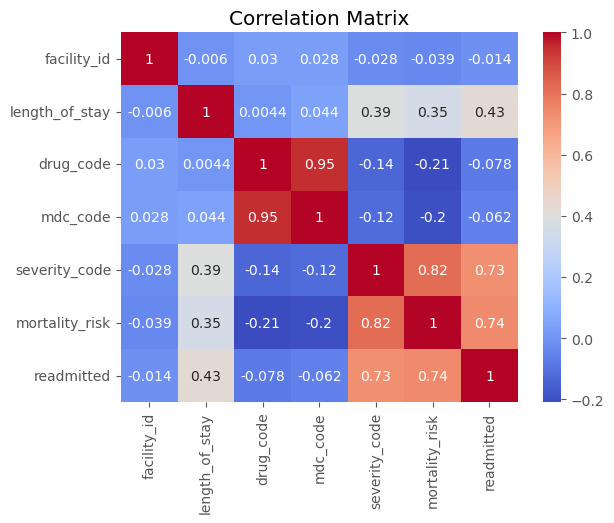

In [53]:

corr = inpatient_cleaned.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

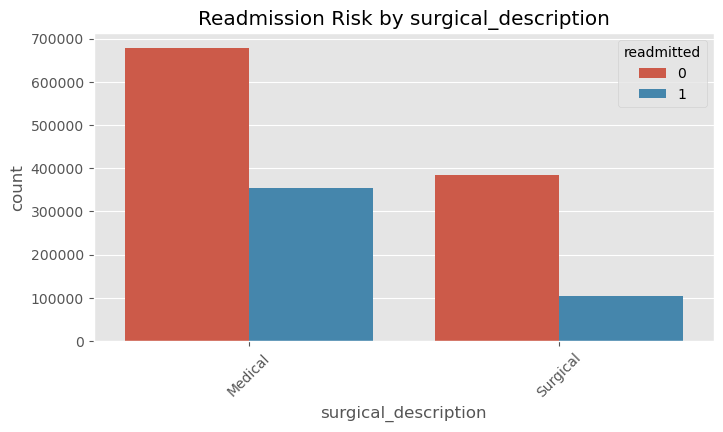

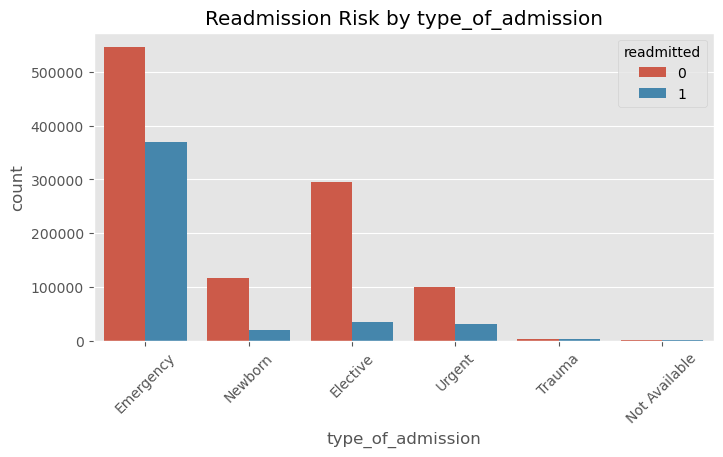

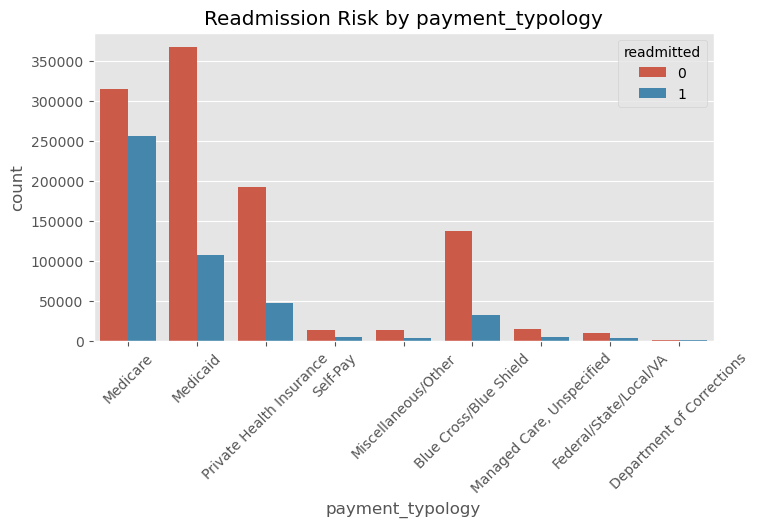

In [54]:
cat_features = ['surgical_description', 'type_of_admission', 'payment_typology']

for col in cat_features:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='readmitted', data=inpatient_df)
    plt.title(f'Readmission Risk by {col}')
    plt.xticks(rotation=45)
    plt.show()

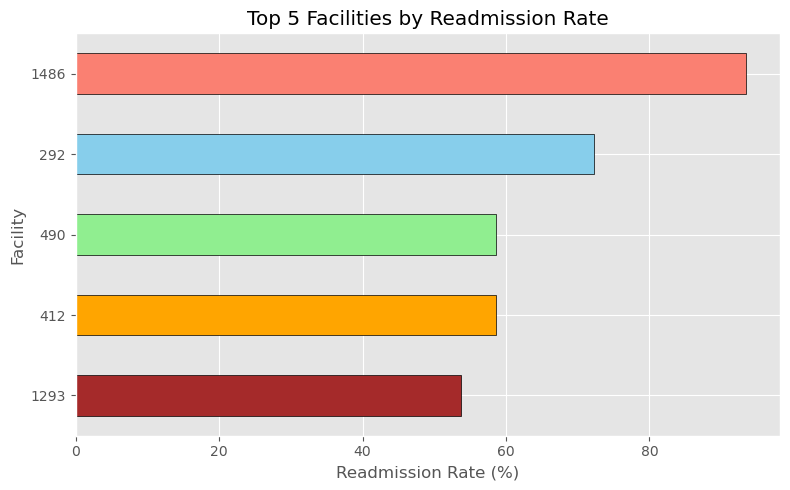

In [55]:

# Step 1: Compute readmission rate per service area
facility_readmission_rate = inpatient_df.groupby('facility_id')['readmitted'].mean() * 100

# Step 2: Sort by rate descending
facility_readmission_rate = facility_readmission_rate.sort_values(ascending=False)

# Step 3: Take top 5 areas
top_facility = facility_readmission_rate.head(5)

# Step 4: Plot
plt.figure(figsize=(8,5))
facility_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']

top_facility.plot(
    kind='barh',
    color=facility_colors,
    edgecolor='black'
)

plt.title('Top 5 Facilities by Readmission Rate')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('Facility')
plt.gca().invert_yaxis()  # optional: highest at the top
plt.tight_layout()
plt.show()


In [56]:
print(facility_map[1486.0])
print(facility_map[292.0])
print(facility_map[490])
print(facility_map[412])
print(facility_map[1293])

Henry J. Carter Specialty Hospital
Sisters of Charity Hospital - St. Joseph Campus
Glen Cove Hospital
Unity Specialty Hospital
New York Community Hospital of Brooklyn, Inc


**Quantitative Methods**

In [57]:
readmit_rate= inpatient_df['readmitted'].mean()
print(readmit_rate *100)

30.087185230167428


**Target variable again**



In [58]:
#Using empirically calibrated weights. This produces a more realistic distribution.

inpatient_df['score_severity']  = inpatient_df['severity_code'] / 4
inpatient_df['score_mortality'] = inpatient_df['mortality_risk'] / 4
inpatient_df['score_surgical']  = (inpatient_df['surgical_description'] == 'Medical').astype(int)
inpatient_df['score_mdc']       = inpatient_df['mdc_code'] / inpatient_df['mdc_code'].max()

inpatient_df['clinical_score'] = (
    0.45 * inpatient_df['score_severity'] +
    0.35 * inpatient_df['score_mortality'] +
    0.15 * inpatient_df['score_surgical'] +
    0.05 * inpatient_df['score_mdc']
)

In [59]:
#using 3 level grouping

group_cols = ['facility_id', 'diagnosis_code', 'mdc_code']

In [60]:
freq = inpatient_df.groupby(group_cols).size().reset_index(name='count_fd')
inpatient_df = inpatient_df.merge(freq, on=group_cols, how='left')

In [62]:
inpatient_df['freq_percentile'] = inpatient_df['count_fd'].rank(pct=True)

KeyError: 'count_fd'

In [65]:
inpatient_df['combined_score'] = (
    0.25 * inpatient_df['freq_percentile'] +
    0.75 * inpatient_df['clinical_score']
)

In [66]:
threshold = inpatient_df['combined_score'].quantile(0.85)
inpatient_df['readmitted'] = (inpatient_df['combined_score'] >= threshold).astype(int)

In [67]:
inpatient_df['readmitted'].mean()

np.float64(0.1500695326198682)

In [68]:
inpatient_df.describe()

,facility_id,length_of_stay,drug_code,mdc_code,severity_code,mortality_risk,count_fd_x,freq_percentile,severity_high,mortality_high,length_of_stay_high,clinical_score,clinical_score_scaled,combined_score,readmitted,score_severity,score_mortality,score_surgical,score_mdc,count_fd_y
count,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00
mean,1073.56,6.23,412.44,10.29,2.20,1.92,589.79,0.50,0.36,0.30,0.27,0.44,0.31,0.45,0.15,0.55,0.48,0.68,0.41,572.89
std,720.04,9.09,238.81,5.76,1.01,1.10,1051.66,0.29,0.48,0.46,0.44,0.20,0.38,0.17,0.36,0.25,0.27,0.47,0.23,1047.17
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.01,0.00,0.00,0.00,0.20,0.00,0.15,0.00,0.25,0.25,0.00,0.04,1.00
25%,541.00,2.00,194.00,5.00,1.00,1.00,68.00,0.25,0.00,0.00,0.00,0.23,0.00,0.33,0.00,0.25,0.25,0.00,0.20,57.00
50%,1165.00,3.00,384.00,9.00,2.00,1.00,216.00,0.50,0.00,0.00,0.00,0.38,0.00,0.42,0.00,0.50,0.25,1.00,0.36,194.00
75%,1456.00,7.00,640.00,15.00,3.00,3.00,632.00,0.75,1.00,1.00,1.00,0.61,0.67,0.55,0.00,0.75,0.75,1.00,0.60,621.00
max,10355.00,120.00,952.00,25.00,4.00,4.00,7170.00,1.00,1.00,1.00,1.00,0.85,1.00,0.87,1.00,1.00,1.00,1.00,1.00,7170.00


In [69]:
inpatient_df

,service_area,county,facility_id,age_group,zip_code,gender,race,ethnicity,length_of_stay,type_of_admission,patient_disposition,diagnosis_code,procedure_code,drug_code,mdc_code,severity_code,mortality_risk,surgical_description,payment_typology,count_fd_x,freq_percentile,severity_high,mortality_high,length_of_stay_high,clinical_score,clinical_score_scaled,combined_score,readmitted,score_severity,score_mortality,score_surgical,score_mdc,count_fd_y
0,New York City,Bronx,1169,70+,104,M,Other Race,Spanish/Hispanic,27,Emergency,Home w/ Home Health Services,INF012,OTR004,137,4,3,4,Medical,Medicare,1224,0.87,1,1,1,0.70,1.00,0.74,1,0.75,1.00,1,0.16,1224
1,New York City,Bronx,1168,18 to 29,104,F,Other Race,Spanish/Hispanic,2,Emergency,Home or Self Care,PRG016,PGN003,540,14,1,1,Surgical,Medicaid,68,0.25,0,0,0,0.23,0.00,0.23,0,0.25,0.25,0,0.56,68
2,New York City,Bronx,3058,70+,104,M,Other Race,Spanish/Hispanic,5,Emergency,Home or Self Care,GEN004,ADM017,463,11,3,3,Medical,Medicare,253,0.54,1,1,0,0.62,0.67,0.60,0,0.75,0.75,1,0.44,253
3,New York City,Bronx,1169,50 to 69,104,F,Black/African American,Not Span/Hispanic,3,Emergency,Home or Self Care,NVS008,CNS002,58,1,2,1,Medical,Medicare,14,0.07,0,0,0,0.31,0.00,0.25,0,0.50,0.25,1,0.04,14
4,New York City,Bronx,3058,50 to 69,105,M,Other Race,Spanish/Hispanic,6,Emergency,Home or Self Care,INJ037,IMG007,813,21,3,2,Medical,Private Health Insurance,262,0.55,1,0,0,0.55,0.33,0.55,0,0.75,0.50,1,0.84,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521583,Hudson Valley,Rockland,776,30 to 49,109,F,Multi-racial,Not Span/Hispanic,5,Emergency,Home or Self Care,NVS002,CNS002,50,1,2,2,Medical,Medicare,2,0.01,0,0,0,0.40,0.00,0.30,0,0.50,0.50,1,0.04,2
1521584,Long Island,Suffolk,913,70+,117,F,White,Not Span/Hispanic,3,Emergency,Skilled Nursing Home,INJ006,MST010,308,8,2,3,Surgical,Medicare,246,0.53,0,1,0,0.50,0.33,0.51,0,0.50,0.75,0,0.32,234
1521585,Long Island,Suffolk,913,70+,117,M,White,Not Span/Hispanic,7,Emergency,Skilled Nursing Home,GEN004,MST023,951,11,3,3,Surgical,Medicare,129,0.38,1,1,1,0.62,1.00,0.56,0,0.75,0.75,0,0.44,129
1521586,Long Island,Suffolk,913,70+,117,M,White,Not Span/Hispanic,3,Emergency,Skilled Nursing Home,INJ033,ESA001,206,5,3,3,Medical,Medicare,77,0.28,1,1,0,0.61,0.67,0.53,0,0.75,0.75,1,0.20,71


In [70]:
inpatient_df.columns

Index(['service_area', 'county', 'facility_id', 'age_group', 'zip_code',
       'gender', 'race', 'ethnicity', 'length_of_stay', 'type_of_admission',
       'patient_disposition', 'diagnosis_code', 'procedure_code', 'drug_code',
       'mdc_code', 'severity_code', 'mortality_risk', 'surgical_description',
       'payment_typology', 'count_fd_x', 'freq_percentile', 'severity_high',
       'mortality_high', 'length_of_stay_high', 'clinical_score',
       'clinical_score_scaled', 'combined_score', 'readmitted',
       'score_severity', 'score_mortality', 'score_surgical', 'score_mdc',
       'count_fd_y'],
      dtype='object')

In [71]:
main_inpatient= inpatient_df[['service_area', 'county', 'facility_id', 'age_group', 'zip_code',
       'gender', 'race', 'ethnicity', 'length_of_stay', 'type_of_admission',
       'patient_disposition', 'diagnosis_code', 'procedure_code', 'drug_code',
       'mdc_code', 'severity_code', 'mortality_risk', 'surgical_description',
       'payment_typology', 'clinical_score', 'combined_score', 'readmitted'
]]

In [72]:
main_inpatient

,service_area,county,facility_id,age_group,zip_code,gender,race,ethnicity,length_of_stay,type_of_admission,patient_disposition,diagnosis_code,procedure_code,drug_code,mdc_code,severity_code,mortality_risk,surgical_description,payment_typology,clinical_score,combined_score,readmitted
0,New York City,Bronx,1169,70+,104,M,Other Race,Spanish/Hispanic,27,Emergency,Home w/ Home Health Services,INF012,OTR004,137,4,3,4,Medical,Medicare,0.70,0.74,1
1,New York City,Bronx,1168,18 to 29,104,F,Other Race,Spanish/Hispanic,2,Emergency,Home or Self Care,PRG016,PGN003,540,14,1,1,Surgical,Medicaid,0.23,0.23,0
2,New York City,Bronx,3058,70+,104,M,Other Race,Spanish/Hispanic,5,Emergency,Home or Self Care,GEN004,ADM017,463,11,3,3,Medical,Medicare,0.62,0.60,0
3,New York City,Bronx,1169,50 to 69,104,F,Black/African American,Not Span/Hispanic,3,Emergency,Home or Self Care,NVS008,CNS002,58,1,2,1,Medical,Medicare,0.31,0.25,0
4,New York City,Bronx,3058,50 to 69,105,M,Other Race,Spanish/Hispanic,6,Emergency,Home or Self Care,INJ037,IMG007,813,21,3,2,Medical,Private Health Insurance,0.55,0.55,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521583,Hudson Valley,Rockland,776,30 to 49,109,F,Multi-racial,Not Span/Hispanic,5,Emergency,Home or Self Care,NVS002,CNS002,50,1,2,2,Medical,Medicare,0.40,0.30,0
1521584,Long Island,Suffolk,913,70+,117,F,White,Not Span/Hispanic,3,Emergency,Skilled Nursing Home,INJ006,MST010,308,8,2,3,Surgical,Medicare,0.50,0.51,0
1521585,Long Island,Suffolk,913,70+,117,M,White,Not Span/Hispanic,7,Emergency,Skilled Nursing Home,GEN004,MST023,951,11,3,3,Surgical,Medicare,0.62,0.56,0
1521586,Long Island,Suffolk,913,70+,117,M,White,Not Span/Hispanic,3,Emergency,Skilled Nursing Home,INJ033,ESA001,206,5,3,3,Medical,Medicare,0.61,0.53,0


In [73]:
main_inpatient.to_csv("sparcs_inpatient_derived.csv", index=False)

Text(0.5, 0, 'combined_score')

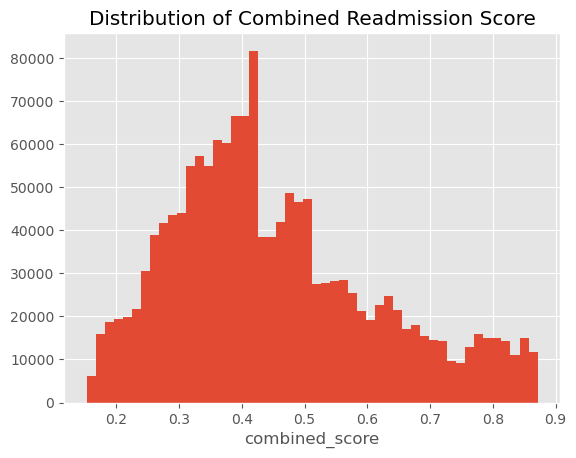

In [74]:
inpatient_df['combined_score'].hist(bins=50)
plt.title('Distribution of Combined Readmission Score')
plt.xlabel('combined_score')

In [75]:
num_vars = ['severity_code', 'mortality_risk', 'length_of_stay', 'clinical_score', 'combined_score']
inpatient_df[num_vars].describe()

,severity_code,mortality_risk,length_of_stay,clinical_score,combined_score
count,1521588.00,1521588.00,1521588.00,1521588.00,1521588.00
mean,2.20,1.92,6.23,0.44,0.45
std,1.01,1.10,9.09,0.20,0.17
min,1.00,1.00,1.00,0.20,0.15
25%,1.00,1.00,2.00,0.23,0.33
50%,2.00,1.00,3.00,0.38,0.42
75%,3.00,3.00,7.00,0.61,0.55
max,4.00,4.00,120.00,0.85,0.87


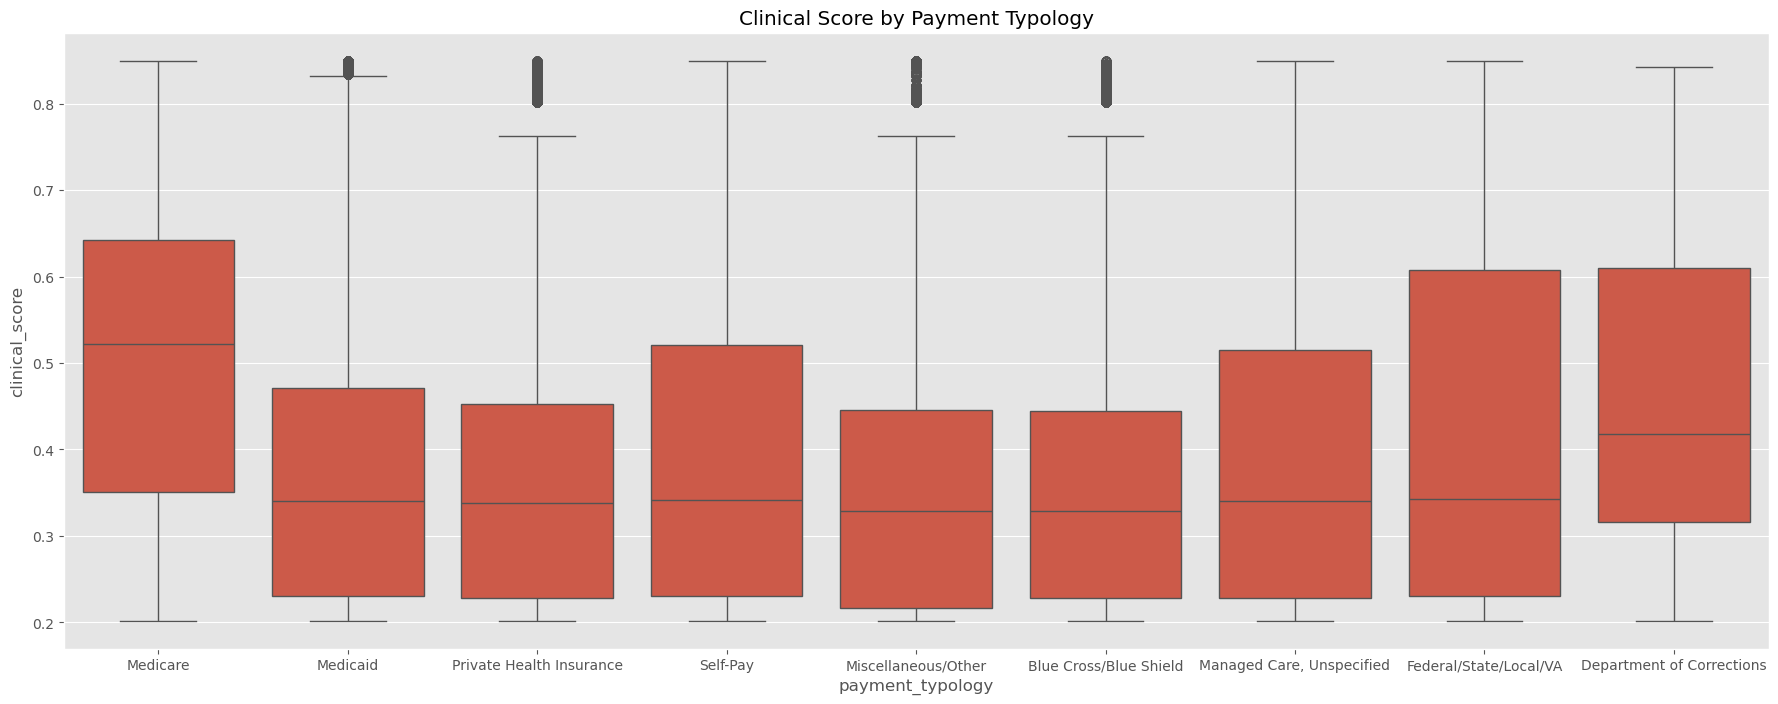

In [76]:
plt.figure(figsize=(22,8))
sns.boxplot(x='payment_typology', y='clinical_score', data=inpatient_df)
plt.title('Clinical Score by Payment Typology')
plt.show()

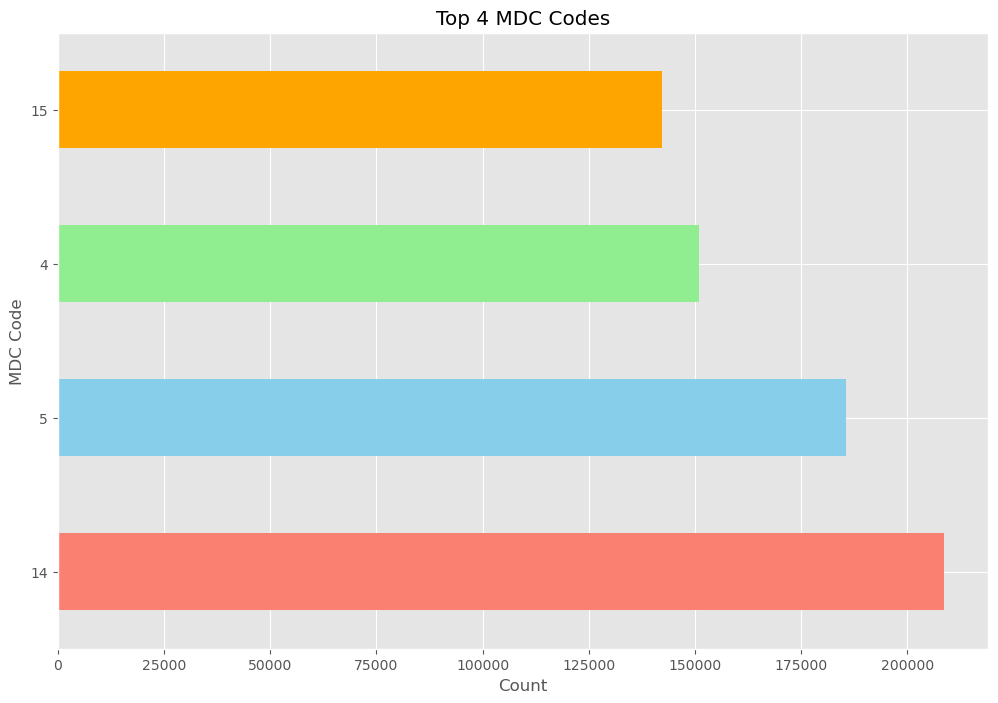

In [77]:
mdc_counts = inpatient_df['mdc_code'].value_counts().head(4)
mdc_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']

plt.figure(figsize=(12,8))
mdc_counts.plot(kind='barh', color=mdc_colors)
plt.title('Top 4 MDC Codes')
plt.xlabel('Count')
plt.ylabel('MDC Code')
plt.show()

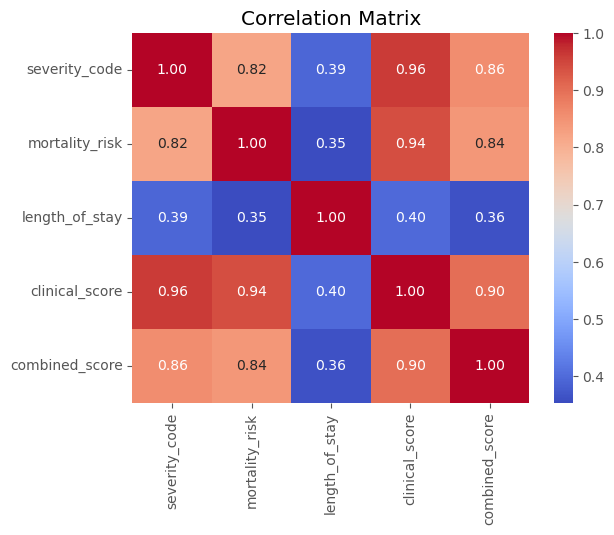

In [78]:
corr = inpatient_df[num_vars].corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [79]:
group_summary = inpatient_df.groupby('payment_typology')['combined_score'].agg(['mean','median','std','count']).reset_index()
print(group_summary)

            payment_typology                 mean               median  \
0     Blue Cross/Blue Shield                 0.41                 0.39   
1  Department of Corrections                 0.43                 0.39   
2     Federal/State/Local/VA                 0.44                 0.40   
3  Managed Care, Unspecified                 0.42                 0.38   
4                   Medicaid                 0.42                 0.40   
5                   Medicare                 0.51                 0.49   
6        Miscellaneous/Other                 0.39                 0.36   
7   Private Health Insurance                 0.42                 0.40   
8                   Self-Pay                 0.43                 0.40   

                   std   count  
0                 0.15  169809  
1                 0.18     745  
2                 0.17   12697  
3                 0.16   18813  
4                 0.15  473583  
5                 0.18  571416  
6                 0.15   166

In [80]:
group_summary.to_csv("payment_and combined.csv", index=False)

In [81]:
mdc_summary = inpatient_df.groupby('mdc_code')['clinical_score'].mean().sort_values(ascending=False)
print(mdc_summary.head(10))

mdc_code
18                   0.69
25                   0.62
4                    0.62
21                   0.55
17                   0.53
11                   0.49
5                    0.48
23                   0.47
7                    0.46
1                    0.45
Name: clinical_score, dtype: float64


**Exploratory Analysis**

In [82]:
target_distribution = inpatient_df['readmitted'].value_counts()
target_distribution

readmitted
0    1293244
1     228344
Name: count, dtype: int64

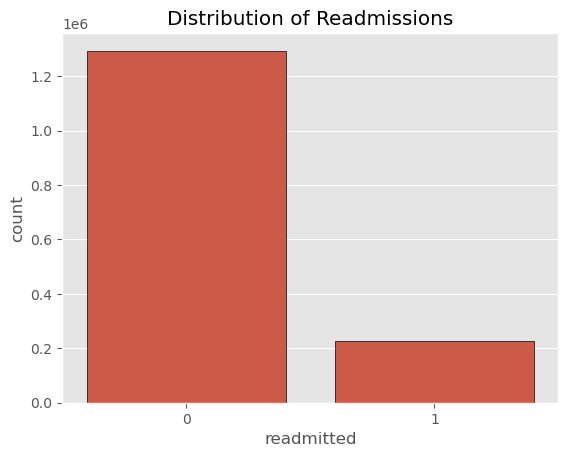

In [83]:
#Distribution of Readmission
sns.countplot(x='readmitted', data=inpatient_df, edgecolor= 'black')
plt.title('Distribution of Readmissions')
plt.show()

In [84]:
rate= (inpatient_df['readmitted'].sum() / len(inpatient_df)) *100
rate

np.float64(15.00695326198682)

In [85]:
rate= (inpatient_df['readmitted'].mean() / len(inpatient_df)) *100
rate

np.float64(9.862691649767756e-06)

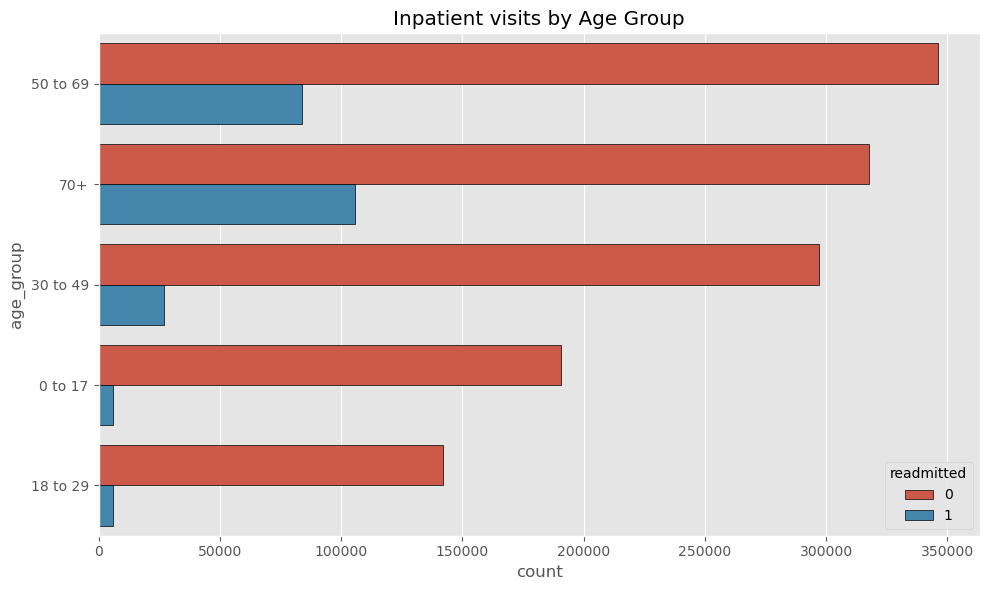

In [86]:
#Age group by readmission rate

fig = plt.figure(figsize=(10,6))

order = inpatient_df['age_group'].value_counts().index

ax=sns.countplot(y= inpatient_df['age_group'], hue= inpatient_df['readmitted'], order=order, edgecolor='black')
ax.set_title('Inpatient visits by Age Group')

plt.tight_layout()
plt.show()

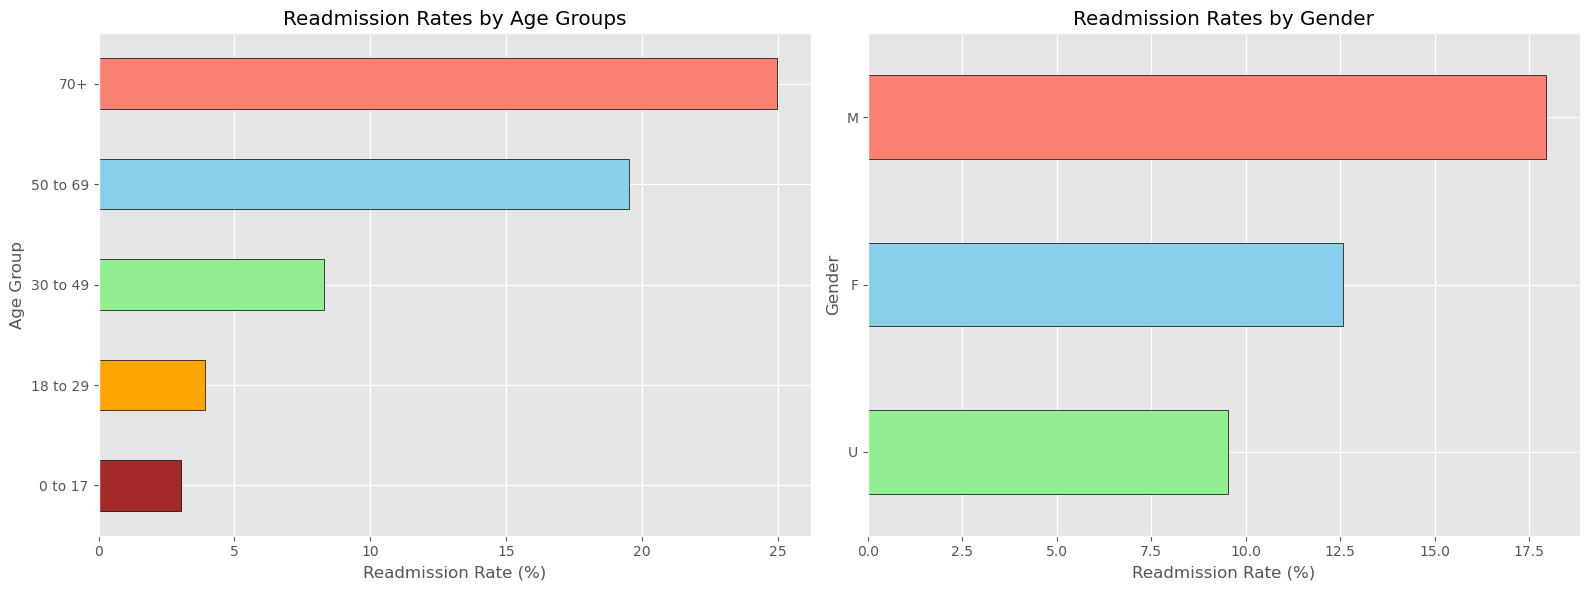

In [87]:
fig = plt.figure(figsize=(16,6))

#readmission rate per age
age_readmission_rate = inpatient_df.groupby('age_group')['readmitted'].mean() * 100

# Step 2: Sort by rate descending
age_readmission_rate = age_readmission_rate.sort_values(ascending=False)

# Step 3: Take top 5 areas
top_age = age_readmission_rate.head(5)

# Step 4: Plot colors
age_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']

plt.subplot(1,2,1)
top_age.plot(
    kind='barh',
    color=facility_colors,
    edgecolor='black'
)
plt.title('Readmission Rates by Age Groups')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('Age Group')
plt.gca().invert_yaxis()  # optional: highest at the top



#Gender
gender_readmission_rate = inpatient_df.groupby('gender')['readmitted'].mean() * 100
gender_readmission_rate = gender_readmission_rate.sort_values(ascending=False)
top_gender = gender_readmission_rate.head(5)

# Step 4: Plot colors
gender_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']

plt.subplot(1,2,2)
top_gender.plot(
    kind='barh',
    color=facility_colors,
    edgecolor='black')

plt.title('Readmission Rates by Gender')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('Gender')
plt.gca().invert_yaxis()  # optional: highest at the top

plt.tight_layout()
plt.show()

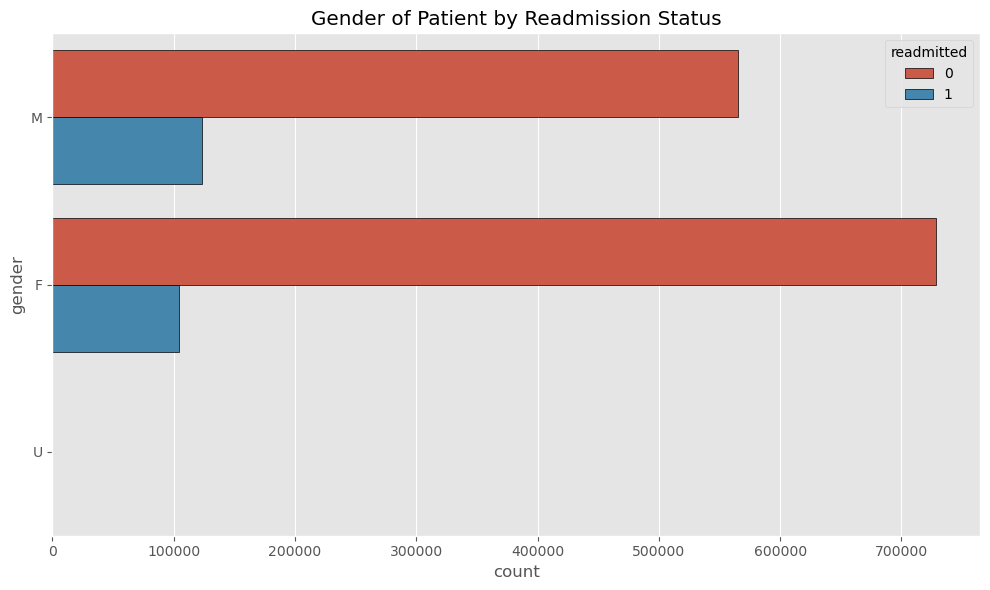

In [88]:
#Gender by readmission rate

fig = plt.figure(figsize=(10,6))
ax=sns.countplot(y= inpatient_df['gender'], hue= inpatient_df['readmitted'], edgecolor='black')
ax.set_title('Gender of Patient by Readmission Status')

plt.tight_layout()
plt.show()

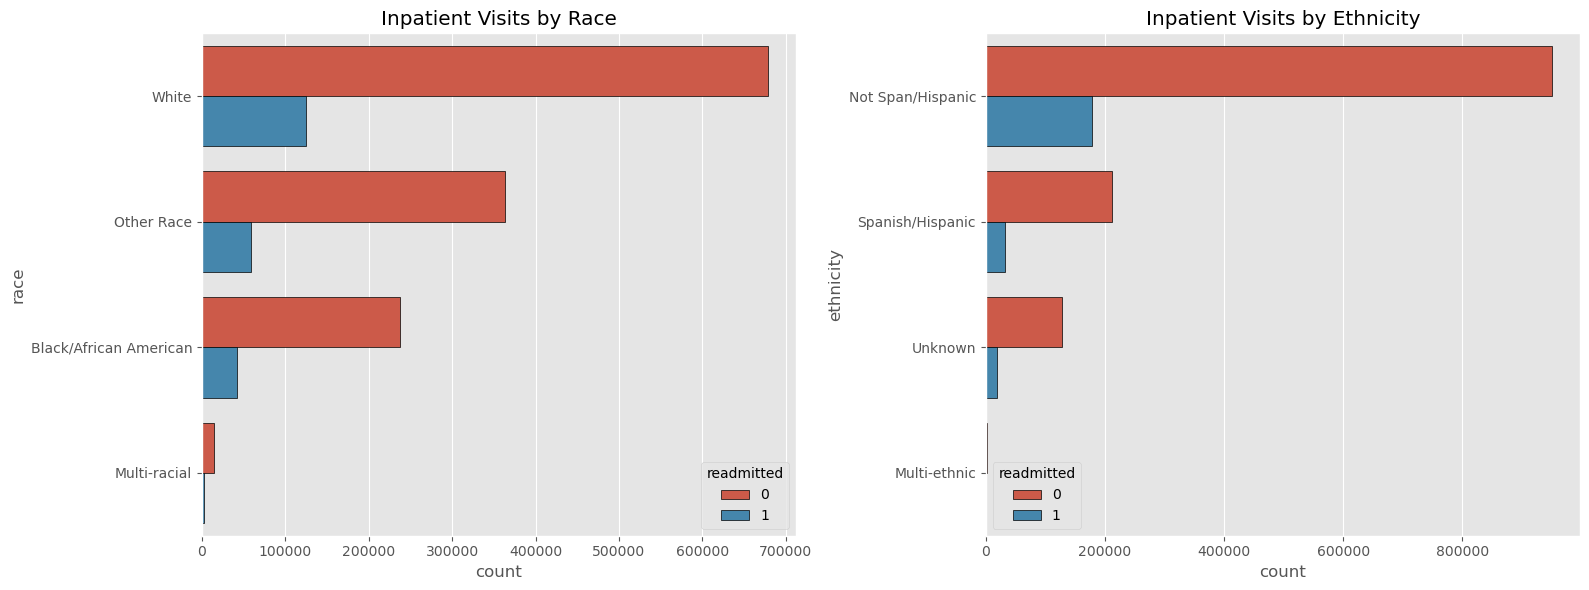

In [89]:
#Race by readmission rate

fig = plt.figure(figsize=(16,6))

order = inpatient_df['race'].value_counts().index
order2 = inpatient_df['ethnicity'].value_counts().index

plt.subplot(1,2,1)
ax=sns.countplot(y= inpatient_df['race'], hue= inpatient_df['readmitted'], order=order, edgecolor='black')
ax.set_title('Inpatient Visits by Race')

plt.subplot(1,2,2)
ax=sns.countplot(y= inpatient_df['ethnicity'], hue= inpatient_df['readmitted'], order=order2, edgecolor='black')
ax.set_title('Inpatient Visits by Ethnicity')


plt.tight_layout()
plt.show()

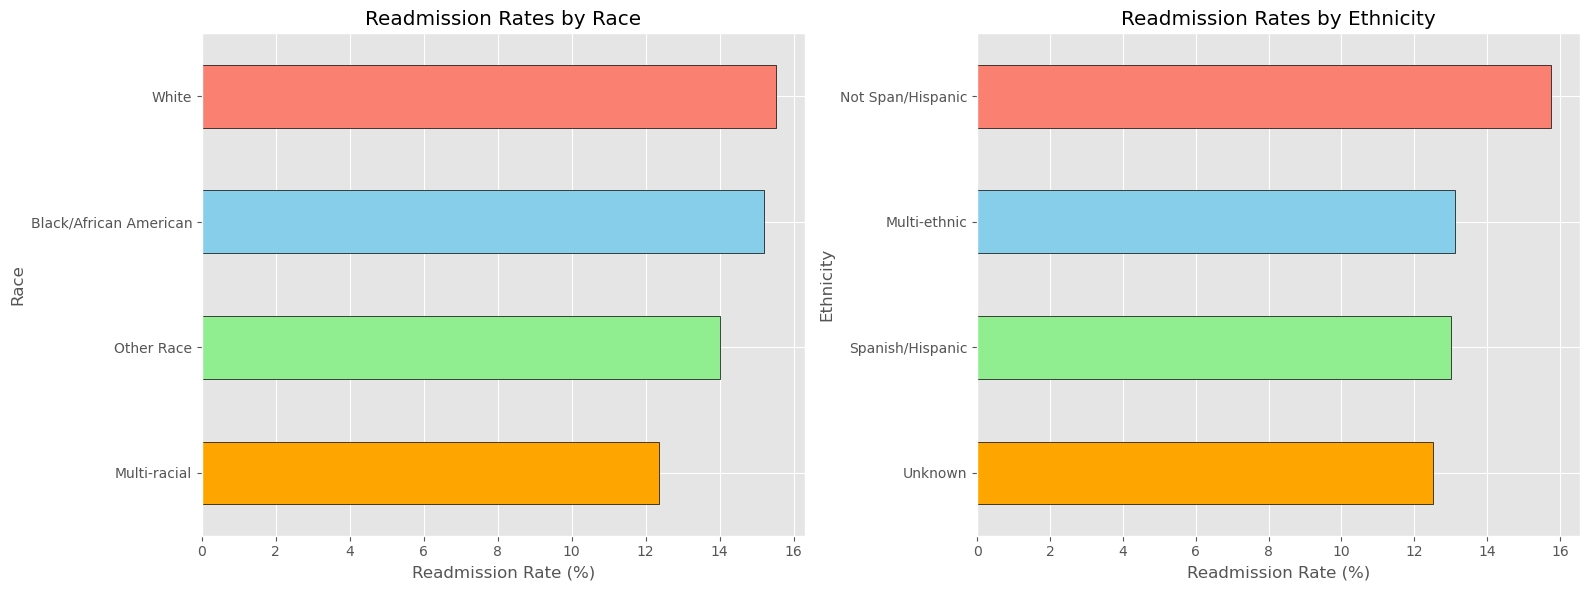

In [90]:
fig = plt.figure(figsize=(16,6))

#readmission rate per age
race_readmission_rate = inpatient_df.groupby('race')['readmitted'].mean() * 100

# Step 2: Sort by rate descending
race_readmission_rate = race_readmission_rate.sort_values(ascending=False)

# Step 3: Take top 5 areas
top_race = race_readmission_rate.head(5)

# Step 4: Plot colors
race_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']

plt.subplot(1,2,1)
top_race.plot(
    kind='barh',
    color=facility_colors,
    edgecolor='black'
)
plt.title('Readmission Rates by Race')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('Race')
plt.gca().invert_yaxis()  # optional: highest at the top



#ethnicity
ethnicity_readmission_rate = inpatient_df.groupby('ethnicity')['readmitted'].mean() * 100
ethnicity_readmission_rate = ethnicity_readmission_rate.sort_values(ascending=False)
top_ethnicity = ethnicity_readmission_rate.head(5)

# Step 4: Plot colors
ethnicity_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']

plt.subplot(1,2,2)
top_ethnicity.plot(
    kind='barh',
    color=facility_colors,
    edgecolor='black')

plt.title('Readmission Rates by Ethnicity')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('Ethnicity')
plt.gca().invert_yaxis()  # optional: highest at the top

plt.tight_layout()
plt.show()

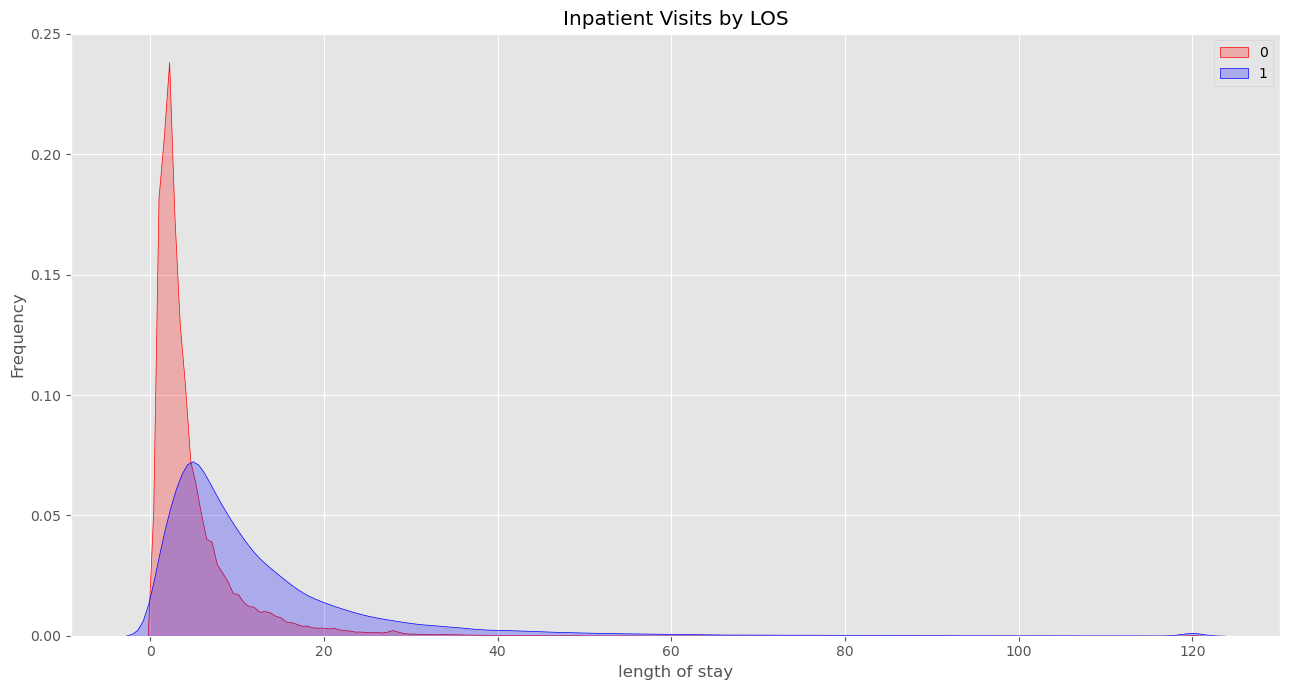

In [91]:
#LOS by readmission rate

fig = plt.figure(figsize=(13,7),)

ax=sns.kdeplot(inpatient_df.loc[(inpatient_df['readmitted'] == 0),'length_of_stay'] , color='r',fill=True,label='Not Readmitted')
ax=sns.kdeplot(inpatient_df.loc[(inpatient_df['readmitted'] == 1),'length_of_stay'] , color='b',fill=True, label='Readmitted')
ax.set(xlabel='length of stay', ylabel='Frequency')
plt.title('Inpatient Visits by LOS')
plt.legend(inpatient_df.index, loc='best')

plt.tight_layout()
plt.show()

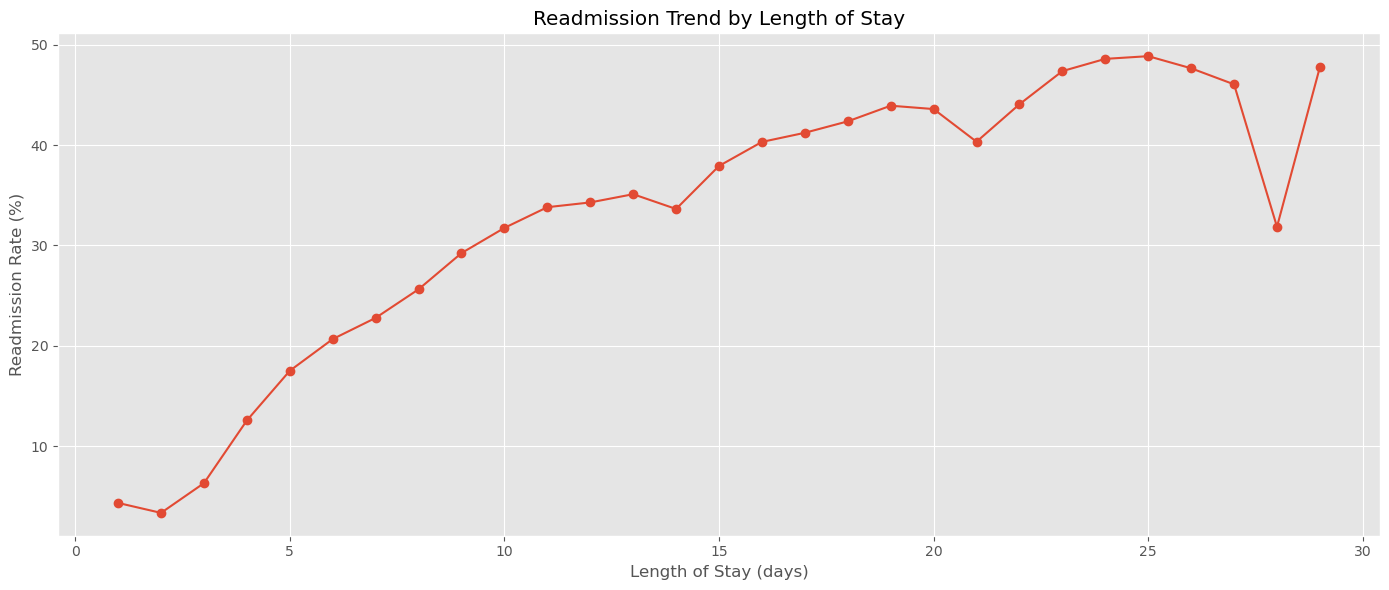

In [92]:
# Filter LOS < 10 and compute readmission rate
los_readmission_rate = (
    inpatient_df[inpatient_df['length_of_stay'] < 30]
    .groupby('length_of_stay')['readmitted']
    .mean() * 100
)

# Sort by LOS (x-axis must be in order)
los_readmission_rate = los_readmission_rate.sort_index()

# Trendline plot
plt.figure(figsize=(14,6))
plt.plot(los_readmission_rate.index, los_readmission_rate.values, marker='o')

plt.title('Readmission Trend by Length of Stay')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Readmission Rate (%)')

plt.grid(True)
plt.tight_layout()
plt.show()

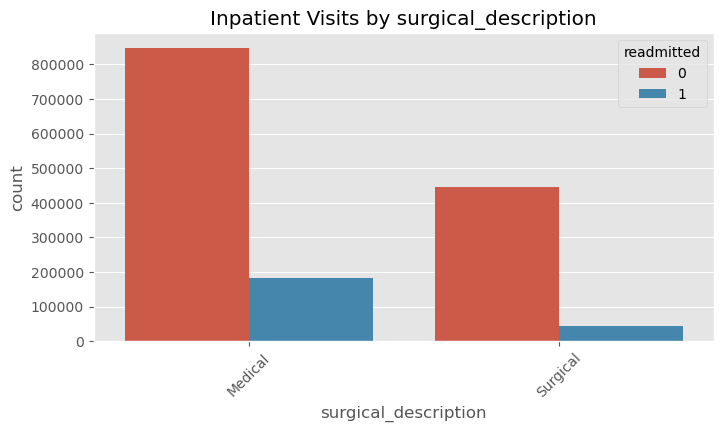

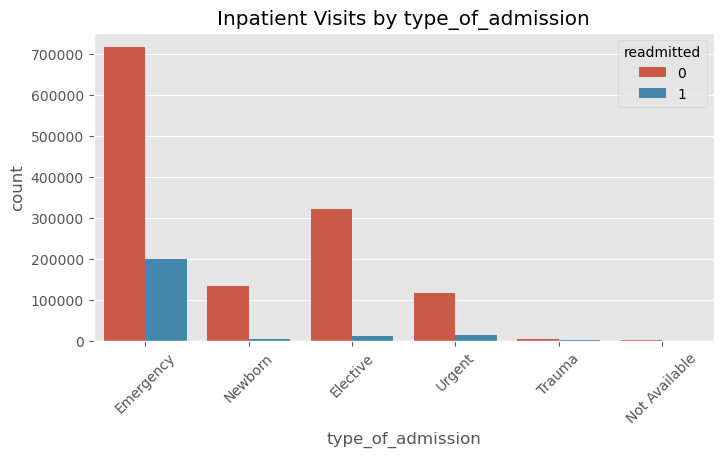

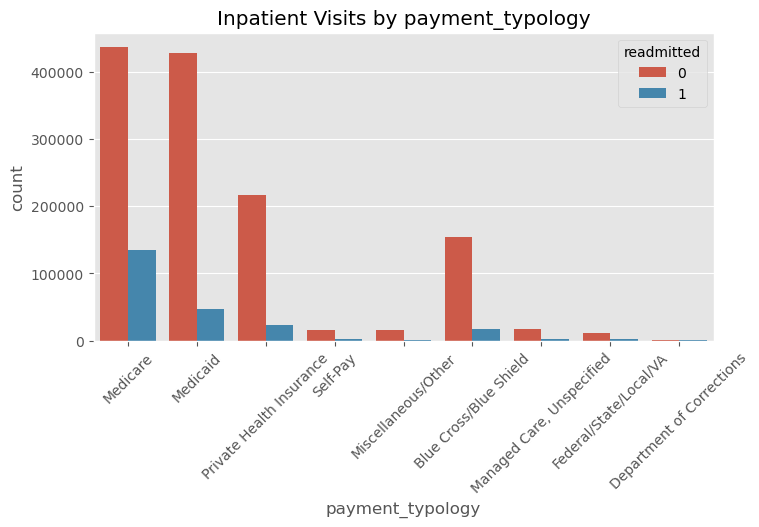

In [93]:
cat_features = ['surgical_description', 'type_of_admission', 'payment_typology']

for col in cat_features:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='readmitted', data=inpatient_df)
    plt.title(f'Inpatient Visits by {col}')
    plt.xticks(rotation=45)
    plt.show()

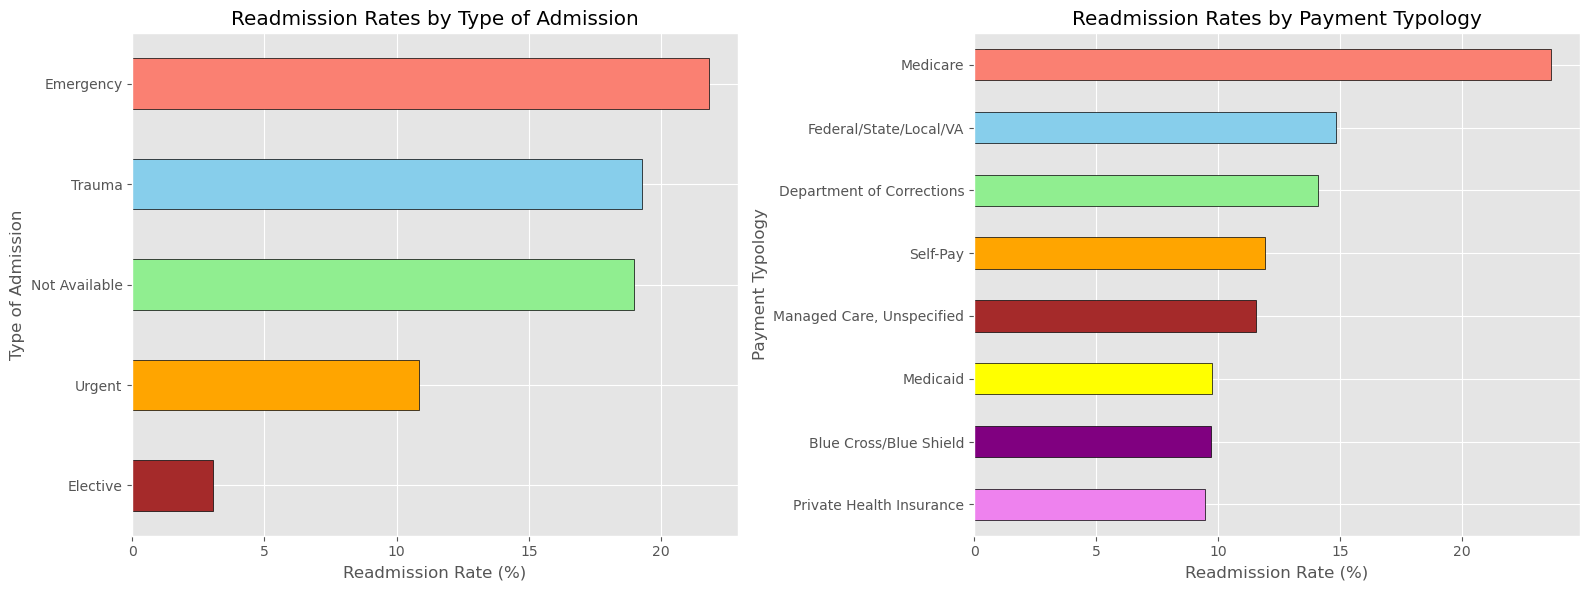

In [94]:
fig = plt.figure(figsize=(16,6))

#readmission rate per age
type_of_admission_readmission_rate = inpatient_df.groupby('type_of_admission')['readmitted'].mean() * 100

# Step 2: Sort by rate descending
type_of_admission_readmission_rate = type_of_admission_readmission_rate.sort_values(ascending=False)

# Step 3: Take top 5 areas
top_type_of_admission = type_of_admission_readmission_rate.head(5)

# Step 4: Plot colors
type_of_admission_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']

plt.subplot(1,2,1)
top_type_of_admission.plot(
    kind='barh',
    color=facility_colors,
    edgecolor='black'
)
plt.title('Readmission Rates by Type of Admission')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('Type of Admission')
plt.gca().invert_yaxis()  # optional: highest at the top



#ethnicity
payment_typology_readmission_rate = inpatient_df.groupby('payment_typology')['readmitted'].mean() * 100
payment_typology_readmission_rate = payment_typology_readmission_rate.sort_values(ascending=False)
top_payment_typology = payment_typology_readmission_rate.head(8)

# Step 4: Plot colors
payment_typology_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown', 'yellow', 'purple', 'violet']

plt.subplot(1,2,2)
top_payment_typology.plot(
    kind='barh',
    color=payment_typology_colors,
    edgecolor='black')

plt.title('Readmission Rates by Payment Typology')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('Payment Typology')
plt.gca().invert_yaxis()  # optional: highest at the top

plt.tight_layout()
plt.show()

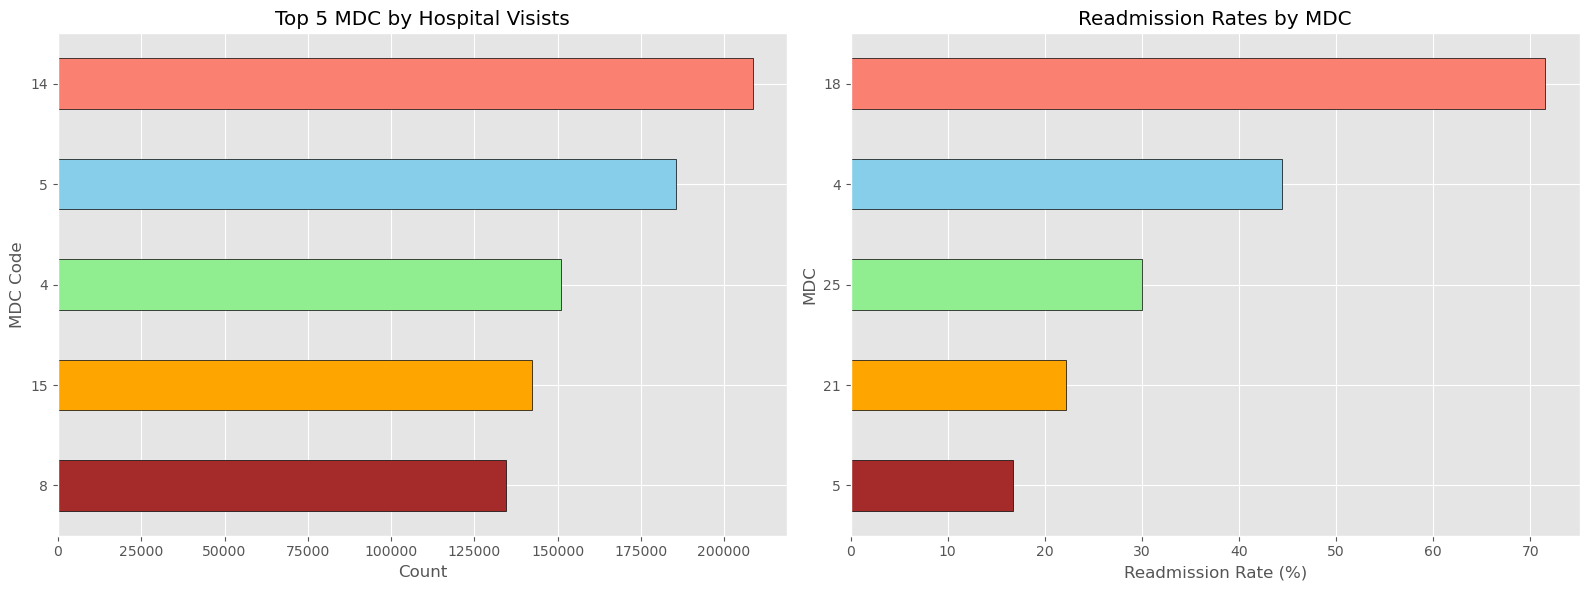

In [95]:
fig = plt.figure(figsize=(16,6))

mdc_counts = inpatient_df['mdc_code'].value_counts().head(5)
mdc_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']

plt.subplot(1,2,1)
mdc_counts.plot(kind='barh', color=mdc_colors, edgecolor='black')
plt.title('Top 5 MDC by Hospital Visists')
plt.gca().invert_yaxis()  # optional: highest at the top
plt.xlabel('Count')
plt.ylabel('MDC Code')


# Step 1: Compute readmission rate per service area
mdc_code_readmission_rate = inpatient_df.groupby('mdc_code')['readmitted'].mean() * 100

# Step 2: Sort by rate descending
mdc_code_readmission_rate = mdc_code_readmission_rate.sort_values(ascending=False)

# Step 3: Take top 5 areas
top_mdc_code = mdc_code_readmission_rate.head(5)

# Step 4: Plot
mdc_code_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']

plt.subplot(1,2,2)
top_mdc_code.plot(
    kind='barh',
    color=mdc_code_colors,
    edgecolor='black'
)

plt.title('Readmission Rates by MDC')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('MDC')
plt.gca().invert_yaxis()  # optional: highest at the top
plt.tight_layout()
plt.show()


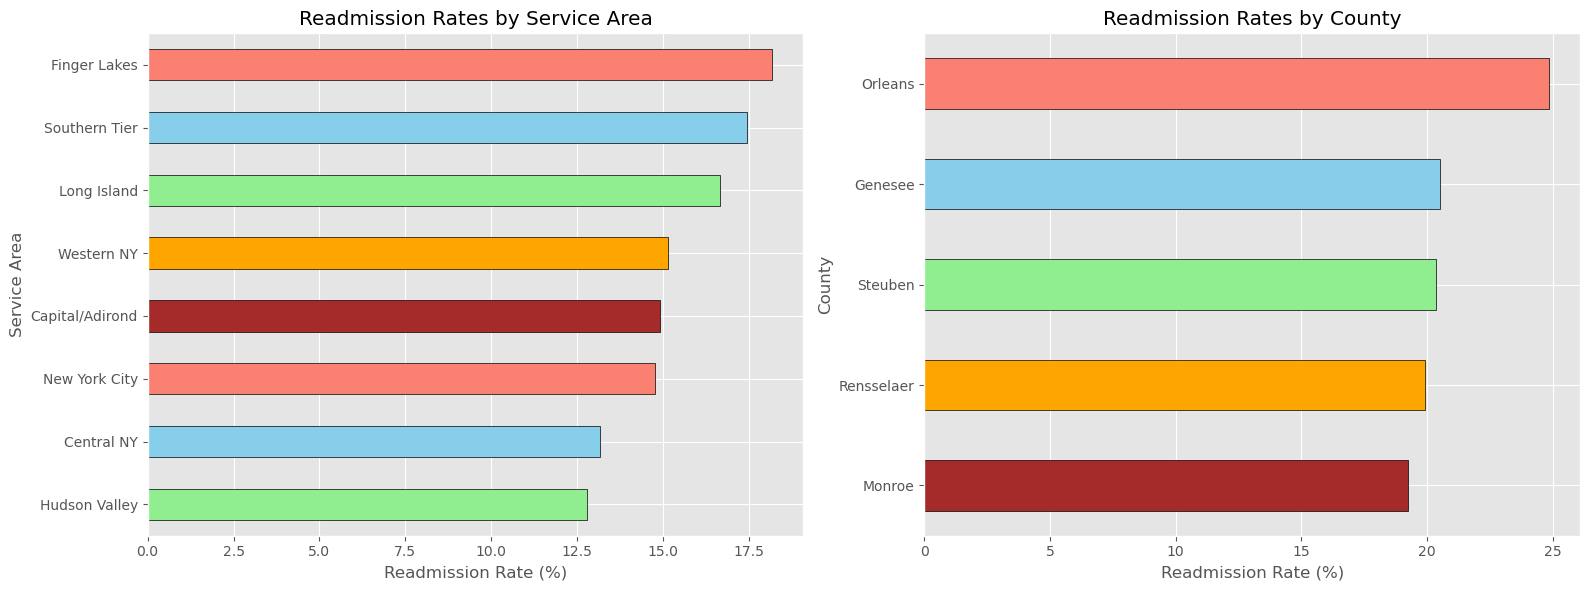

In [96]:
fig = plt.figure(figsize=(16,6))

#readmission rate per service_area
service_area_readmission_rate = inpatient_df.groupby('service_area')['readmitted'].mean() * 100

# Step 2: Sort by rate descending
service_area_readmission_rate = service_area_readmission_rate.sort_values(ascending=False)

# Step 3: Take top 5 areas
top_service_area = service_area_readmission_rate.head(10)

# Step 4: Plot colors
service_area_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']

plt.subplot(1,2,1)
top_service_area.plot(
    kind='barh',
    color=service_area_colors,
    edgecolor='black'
)
plt.title('Readmission Rates by Service Area')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('Service Area')
plt.gca().invert_yaxis()  # optional: highest at the top



#county
county_readmission_rate = inpatient_df.groupby('county')['readmitted'].mean() * 100
county_readmission_rate = county_readmission_rate.sort_values(ascending=False)
top_county = county_readmission_rate.head(5)

# Step 4: Plot colors
county_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown', 'yellow', 'purple', 'violet']

plt.subplot(1,2,2)
top_county.plot(
    kind='barh',
    color=county_colors,
    edgecolor='black')

plt.title('Readmission Rates by County')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('County')
plt.gca().invert_yaxis()  # optional: highest at the top

plt.tight_layout()
plt.show()

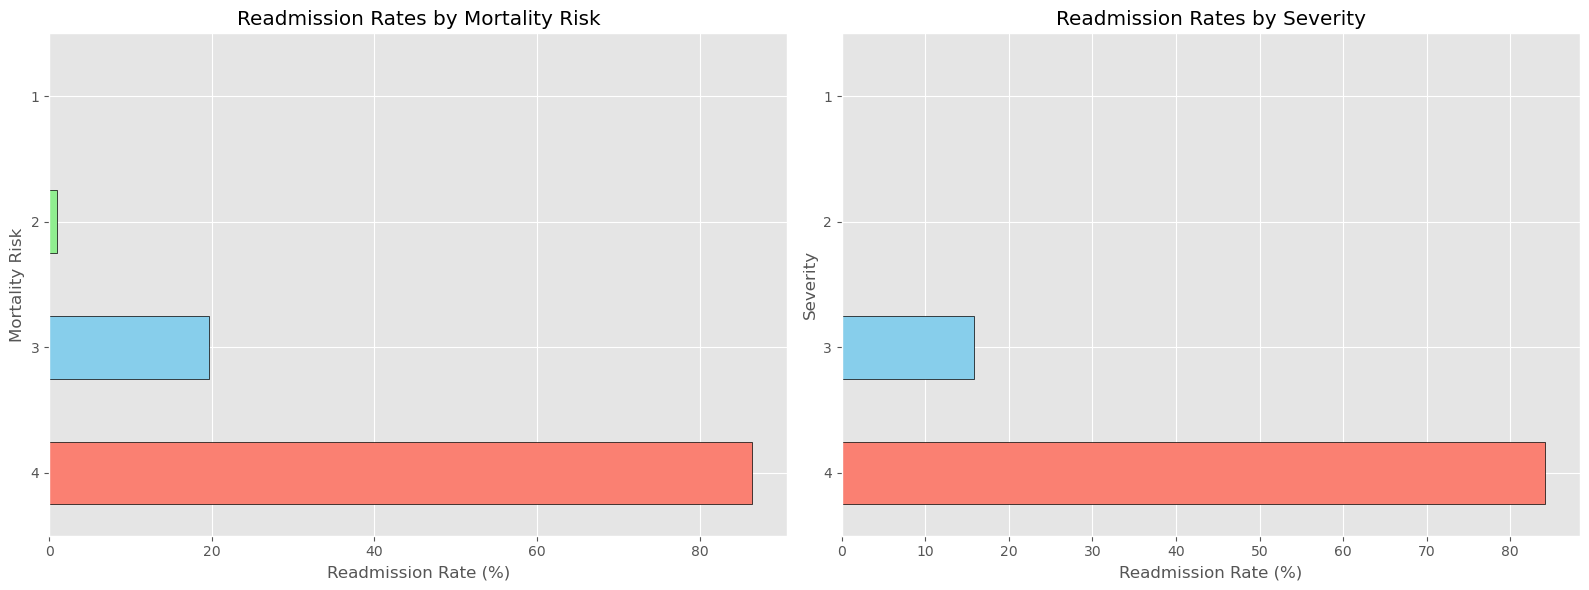

In [100]:
fig = plt.figure(figsize=(16,6))

#readmission rate per mortality_risk
mortality_risk_readmission_rate = inpatient_df.groupby('mortality_risk')['readmitted'].mean() * 100

# Step 2: Sort by rate descending
mortality_risk_readmission_rate = mortality_risk_readmission_rate.sort_values(ascending=False)

# Step 3: Take top 5 areas
top_mortality_risk = mortality_risk_readmission_rate.head(10)

# Step 4: Plot colors
mortality_risk_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown']

plt.subplot(1,2,1)
top_mortality_risk.plot(
    kind='barh',
    color=mortality_risk_colors,
    edgecolor='black'
)
plt.title('Readmission Rates by Mortality Risk')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('Mortality Risk')
#plt.gca().invert_yaxis()  # optional: highest at the top



#severity_code
severity_code_readmission_rate = inpatient_df.groupby('severity_code')['readmitted'].mean() * 100
severity_code_readmission_rate = severity_code_readmission_rate.sort_values(ascending=False)
top_severity_code = severity_code_readmission_rate.head(5)

# Step 4: Plot colors
severity_code_colors = ['salmon', 'skyblue', 'lightgreen', 'orange', 'brown', 'yellow', 'purple', 'violet']

plt.subplot(1,2,2)
top_severity_code.plot(
    kind='barh',
    color=severity_code_colors,
    edgecolor='black')

plt.title('Readmission Rates by Severity')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('Severity')
#plt.gca().invert_yaxis()  # optional: highest at the top

plt.tight_layout()
plt.show()

In [98]:
service_area
mortality_risk
severity_code

NameError: name 'service_area' is not defined

In [ ]:
#readmission rate

# Calculate the percentage distribution of each readmission category
readmission_percentage = readmission_distribution.div(readmission_distribution.sum(axis=1), axis=0) * 100

plt.legend(title="Readmission Status", bbox_to_anchor=(1,1))

use barplots not count plots (sns barplot)